## Abstract:


We generate realistic rough fracture walls by synthesizing **self-affine (fractal) surfaces** with an FFT method: roughness grows with scale as
$$
\sigma_{\delta h}(\Delta \ell)\propto \Delta \ell^{H},
$$
and we enforce a power-law spectrum by prescribing Fourier amplitudes
$$
A(K)\propto K^{-\beta/2},\qquad \beta=2H+1,
$$
with random phases and an inverse transform
$$
z(x,y)=\Re{\mathrm{IFFT}[\hat z]}.
$$
The surface is then rescaled to match the target roughness magnitude (linked to JRC):
$$
z \leftarrow z,\frac{\sigma_{\delta h,\text{target}}}{\sigma_{\delta h,\text{num}}},
$$
and two perfectly mated walls are formed around an initial aperture (b_0):
$$
z_{\text{lower}}=-\tfrac12 z-\tfrac12 b_0,\qquad z_{\text{upper}}=+\tfrac12 z+\tfrac12 b_0.
$$

Next, we simulate **shear damage and closure under stress**. Local slopes facing the shear direction are evaluated and asperities are progressively degraded when sliding demand exceeds resistance, using a Mohr–Coulomb form
$$
\tau=c_{\text{joint}}+\sigma_n\tan\varphi,
$$
with (\varphi) and JCS varying with (\sigma_n). After shearing (implemented as slope-clipping plus a periodic shift of one wall), we compute the spatially varying aperture using the mid-plane geometry
$$
a=\max!\left(\frac{\Delta z_c}{n_{m,z}},0\right).
$$
Finally, normal compression is applied with a Barton–Bandis hyperbola
$$
\Delta b_n(\sigma_n)=\frac{\sigma_n}{\sigma_n+k_n\Delta b_m},\Delta b_m,
$$
giving the closed aperture field
$$
a_{\text{closed}}=\max(a-\Delta b_n,0).
$$




## 1. Self-affine synthetic fracture surfaces (Stigsson-type, FFT)

Fracture surfaces are represented as **self-affine mono-fractal** surfaces, following the approach of Stigsson and Mas Ivars (2018) and Stigsson *et al.* (2025).
The fracture geometry is described by a height (or aperture) function $a(x,y)$ defined over a planar domain; $a(x,y)$ is the elevation of the surface above a reference plane. In the implementation, $a(x,y)$ and $z(x,y)$ are used interchangeably as the surface height.

A self-affine surface is characterized by:

1. The **Hurst exponent** $H$, which controls how roughness grows with scale. For a self-affine surface embedded in 3D,
   $$
   H = 3 - D_\mathrm{surface},
   $$
   where $D_\mathrm{surface}$ is the fractal dimension of the surface. A smooth plane has $D_\mathrm{surface} = 2$ and $H = 1$; rougher surfaces have $D_\mathrm{surface} \to 3$ and thus smaller $H$.

2. A **magnitude parameter** for the height differences, usually taken as the standard deviation of height differences $\sigma_{\delta h}(\Delta \ell)$ at a given lag $\Delta \ell$.

For a one-dimensional trace $h(x)$ of the surface, the height difference over a step $\Delta \ell$ is
$$
\delta h(x;\Delta \ell) = h(x + \Delta \ell) - h(x),
$$

and the corresponding standard deviation is

$$
\sigma_{\delta h}(\Delta \ell)
=\sqrt{\big\langle \big[h(x+\Delta \ell) - h(x)\big]^2 \big\rangle},
$$
where $\langle\cdot\rangle$ denotes averaging along the profile. Following Stigsson *et al.*, the reference lag is
$$
\Delta \ell = 1,\mathrm{mm}
\quad\Rightarrow\quad
\sigma_{\delta h}(1,\mathrm{mm}).
$$

### 1.1 JRC--$H$--$\sigma_{\delta h}$ link

Stigsson and Mas Ivars link the fractal parameters $(H, \sigma_{\delta h})$ to the classical Joint Roughness Coefficient (JRC) by fitting a multiple linear regression model to Barton’s ten standard roughness profiles. This regression provides a continuous mapping between an engineering $\mathrm{JRC}$ value and the pair $(H,\sigma_{\delta h}(1\,\mathrm{mm}))$, where $\sigma_{\delta h}(1\,\mathrm{mm})$ is expressed in meters.

In the present implementation, this regression is \emph{not} re-derived and evaluated. Instead, the published anchor values reported by Stigsson for the parameter study are used directly:


 1. $\mathrm{JRC}=4,7,10$,
 2. corresponding $H=0.7,0.8,0.9$,
 3. corresponding $\sigma_{\delta h}(1\,\mathrm{mm}) = 0.0969,\,0.1440,\,0.1910\ \mathrm{mm}$.


**Reason:** using the published anchor values is simpler and guarantees exact consistency with Stigsson \emph{et al.} for these studied $\mathrm{JRC}$ values, without re-implementing the regression.

Self-affine scaling implies
$$
\sigma_{\delta h}(\Delta \ell) \propto \Delta \ell^{H},
$$
so for a grid spacing $dx$ (in meters):
$$
\sigma_{\delta h}(1\,\mathrm{mm})
= \sigma_{\delta h}(dx)\left(\frac{1\,\mathrm{mm}}{dx}\right)^{H},
\qquad
\sigma_{\delta h}(dx)
= \sigma_{\delta h}(1\,\mathrm{mm})\left(\frac{dx}{1\,\mathrm{mm}}\right)^{H}.
$$
These relations allow conversion between roughness measured at a given sampling step $dx$ and the value required in the JRC-based parameterisation.



In the present implementation, this **continuous** JRC–$H$–$\sigma_{\delta h}$ relation is *not* recomputed. Instead, a **fixed table** is used for three JRC values taken directly from Stigsson’s parameter study:

* $\mathrm{JRC} = 4, 7, 10$,
* corresponding $H = 0.7, 0.8, 0.9$,
* corresponding $\sigma_{\delta h}(1,\mathrm{mm}) = 0.0969, 0.1440, 0.1910\ \mathrm{mm}$.

**Reason:** using the published table is simpler and guarantees exact consistency with Stigsson *et al.* for the studied JRC values, without re-implementing the regression.

In this work, $\mathrm{JRC}\in[4,10]$ and $\sigma_n\in[0.2,20]\,\mathrm{MPa}$ are enforced to avoid extrapolation beyond the published anchor parameterisation; values outside these ranges are rejected.


### 1.2 Power spectrum and FFT-based generation

To generate synthetic self-affine surfaces with prescribed $H$ and $\sigma_{\delta h}$, Stigsson *et al.* use a **spectral (FFT-based)** method. The (one-dimensional) power spectral density is assumed to follow a power law
$$
S(f) = c_I, f^{-\beta_\mathrm{ps}},
$$
with spectral slope
$$
\beta_\mathrm{ps} = 2H + 1,
$$
which is the standard relation for self-affine profiles. The intercept $c_I$ is chosen such that the resulting surface has the target $\sigma_{\delta h}(1,\mathrm{mm})$.

In the present work, the same idea is implemented directly in **2D**:

1. A periodic grid of size $2049 \times 2049$ points is defined, with
   $$
   \Delta x = \Delta y = 1,\mathrm{mm},
   $$
   giving a domain of about $2.049 \times 2.049,\mathrm{m}^2$.

2. FFT frequencies $(k_x, k_y)$ are computed in both directions and the radial wavenumber
   $$
   K = \sqrt{k_x^2 + k_y^2}
   $$
   is formed.

3. The spectral amplitude is prescribed as
   $$
   A(K) \propto K^{-\beta_\mathrm{ps}/2}, \qquad A(0) = 0,
   $$
   and a **band-limit** is applied: only modes with
   $$
   K_\mathrm{min} \leq K \leq K_\mathrm{max}
   $$
   are kept. Here $K_\mathrm{min}$ and $K_\mathrm{max}$ are determined from

   * the grid fundamental and Nyquist frequencies, and
   * optional user-specified smallest and largest wavelengths $\lambda_\mathrm{min},\lambda_\mathrm{max}$.

   Stigsson *et al.* use the grid-implied band; introducing an explicit $[\lambda_\mathrm{min},\lambda_\mathrm{max}]$ is a controlled simplification.

    **Reason:** the band-limit avoids injecting wavelengths that are (i) larger than the domain scale (not statistically meaningful in a finite window) or (ii) smaller than the grid resolution (aliasing / numerical noise), and it allows controlled comparison of roughness content across cases.


4. Independent random phases $\theta(\mathbf{k}) \sim \mathcal{U}(0,2\pi)$ are drawn and the complex spectrum is built as
   $$
   \hat z(\mathbf{k})
   = A(K)\bigl(\cos\theta(\mathbf{k}) + i\sin\theta(\mathbf{k})\bigr).
   $$

5. A 2D inverse FFT yields a real surface
   $$
   z_\mathrm{big}(x,y) = \Re{\mathrm{IFFT}[\hat z]},
   $$
   which is then shifted to zero mean.

This is the same conceptual spectral method as in Stigsson and Mas Ivars (power-law spectrum + random phase), applied in two spatial dimensions.

### 1.3 Numerical calibration to $\sigma_{\delta h}(1,\mathrm{mm})$

In the original formulation, the spectral intercept $c_I$ is derived analytically so that the generated surface has the correct $\sigma_{\delta h}(1,\mathrm{mm})$.

Here, the intercept is **not** computed analytically. Instead, the amplitude is calibrated **numerically** on the discrete grid:

* The standard deviation of adjacent height differences is computed as
  $$
  \sigma_{\delta h,\text{num}}
  = \mathrm{std}\Bigl(z_{i+1,j} - z_{i,j},; z_{i,j+1} - z_{i,j}\Bigr),
  $$
  using all horizontal and vertical neighbour pairs.

* The surface is rescaled as
  $$
  z_\mathrm{big}
  ;\leftarrow;
  z_\mathrm{big},
  \frac{\sigma_{\delta h,\text{target}}}{\sigma_{\delta h,\text{num}}},
  $$
  where $\sigma_{\delta h,\text{target}}$ is the value implied by the chosen JRC and $H$ (through the Stigsson table).

**Reason:** this avoids reproducing the somewhat involved analytic expression for $c_I$ and enforces the target $\sigma_{\delta h}(1,\mathrm{mm})$ *exactly* on the discrete grid. The statistical outcome is equivalent to the original method within numerical accuracy.

### 1.4 Extraction and mated walls

Following Stigsson *et al.*, a larger periodic surface is first generated and then a central window is extracted to obtain the target domain size::

* A central $1001 \times 1001$ window is extracted from the $2049 \times 2049$ field, corresponding to $1.0 \times 1.0,\mathrm{m}^2$ at $1,\mathrm{mm}$ resolution.

* The mean is removed:
  $$
  z_0(x,y) = z(x,y) - \langle z\rangle.
  $$

* Two perfectly mated fracture walls are then defined as
    $$
    z_{\mathrm{lower}}(x,y) = -\tfrac{1}{2} z_0(x,y) - \tfrac{1}{2} b_0,\qquad
    z_{\mathrm{upper}}(x,y) = +\tfrac{1}{2} z_0(x,y) + \tfrac{1}{2} b_0,
    $$
    where $b_0$ is the prescribed initial mechanical aperture.


In this way, the initial joint consists of two statistically self-affine, exactly matching surfaces, consistent with the assumptions in Stigsson *et al.*, but implemented explicitly on a structured grid.


---

## 2. Shear damage (semi-analytical model of Casagrande *et al.*)

The shear damage algorithm is based on the semi-analytical model proposed by Casagrande *et al.* (2018).

The original method:

* discretises the joint into triangular facets,
* computes a local apparent dip $\beta_{\mathrm{app},i}$ for each facet,
* evaluates shear-breakage and sliding forces on sets of facets with $\beta_{\mathrm{app},i} \geq \beta^*$,
* iterates over decreasing thresholds $\beta^*$.

The implementation follows this **logic** but uses regular grid cells instead of triangles.

### 2.1 Apparent dip

For shear in $x$, the apparent dip per cell is computed as

$$
\beta_{fs}
= \arctan\left(
\frac{z_{i+1,j} + z_{i+1,j+1} - z_{i,j} - z_{i,j+1}}{2,\Delta x}
\right),
$$

(and an analogous expression for shear in $y$).

The function `compute_apparent_dip_signed` returns the signed $\beta_{fs}$ in degrees for each cell.

### 2.2 Shear and sliding forces

Casagrande *et al.* define two macroscopic forces over a set of contributing facets:

* shear-breakage resistance
  $$
  F_\mathrm{shear}
  = \sum_{cf} a_{cf}
  \left(c_\mathrm{joint} + \sigma_{N,cf} \tan\varphi\right),
  $$
* sliding resistance
  $$
  F_\mathrm{slide}
  = \sum_{cf} a_{cf},
  \sigma_{N,cf},\tan\bigl(\varphi_b + \beta_{fs}\bigr),
  $$

with cell area $a_{cf} = \Delta x,\Delta y$, joint cohesion $c_\mathrm{joint}$, friction angle $\varphi$, basic friction angle $\varphi_b$ and local normal stress $\sigma_{N,cf}$.

In the present model:

* facets are grid cells,
* only facets with $\beta_{fs} > 0$ (facing shear) contribute to $F_\mathrm{slide}$,
* the local normal stress is approximated as in Stigsson *et al.*:
  $$
  \sigma_{N,cf}
  = \min\left(\frac{\sigma_n}{\cos\beta_{fs}},\ \mathrm{JCS}\right),
  $$
  with JCS from a stress-dependent table (Section 3).

This is implemented in `calculate_forces_facetwise`.

### 2.3 Facet activation and iteration over $\beta^*$

As in Casagrande *et al.*, facets are activated by a threshold $\beta^*$:

1. for a given $\beta^*$, all cells with $|\beta_{fs}| \geq \beta^*$ are marked as active;
2. $F_\mathrm{shear}$ and $F_\mathrm{slide}$ are computed over active cells;
3. if $F_\mathrm{slide} \geq F_\mathrm{shear}$, these cells are considered to shear (geometry is altered); otherwise $\beta^*$ is reduced.

The function `casagrande_shear_v3` starts from the current maximum apparent dip $\beta_\mathrm{max}$ and decreases $\beta^*$ in steps of $0.5^\circ$ until no more shearing occurs.

### 2.4 Geometry update: slope clipping via Poisson solve

Casagrande *et al.* update geometry by enforcing shear along a plane at $\beta^*$ and then correcting steps; this is formulated for triangular facets.

The implementation replaces this with a regular-grid procedure:

1. compute node-based gradients
   $$
   g_x = \frac{\partial z}{\partial x},\quad
   g_y = \frac{\partial z}{\partial y}
   $$
   with periodic finite differences;
2. map active cells to \textbf{active nodes} (all nodes that belong to at least one active cell);
3. on active nodes, clip the gradient component in shear direction (e.g. $g_s = g_x$ for shear in $x$) to
   $$
   |g_s| \leq \tan \beta^*,
   $$
   leaving the transverse component unchanged;
4. define the gradient correction $\delta \mathbf{g}$ and solve
   $$
   \nabla^2 \delta z = \nabla\cdot\delta \mathbf{g}
   $$
   in Fourier space with periodic boundary conditions;
5. update the surface: $z \leftarrow z + \delta z$.

**Reason:** this keeps the Casagrande mechanism (reduction of apparent dip in facets that satisfy the force criterion) but is \textbf{much simpler to implement} on a regular grid than the original triangular facet scheme. It also avoids artificial large-scale tilts by enforcing gradient consistency via the Poisson solve.
The Poisson problem is solved in Fourier space assuming **periodic boundary conditions**, consistent with the FFT-based surface representation.

---

## 3. Stress-dependent friction and JCS (Barton-type)


The stress dependence of friction angle $\varphi$ and JCS follows the Forsmark parameterisation used by Stigsson *et al.* based on Barton’s work.

Instead of a purely discrete table, the implementation uses a **continuous, anchor-based interpolation** defined by three literature points:

* at $\sigma_n = 0.2,\mathrm{MPa}$:
  $$
  \varphi = 60^\circ,\quad \mathrm{JCS} = 209,\mathrm{MPa},
  $$
* at $\sigma_n = 2,\mathrm{MPa}$:
  $$
  \varphi = 50^\circ,\quad \mathrm{JCS} = 153,\mathrm{MPa},
  $$
* at $\sigma_n = 20,\mathrm{MPa}$:
  $$
  \varphi = 30^\circ,\quad \mathrm{JCS} = 97,\mathrm{MPa}.
  $$

For intermediate stresses, $\varphi(\sigma_n)$ and $\mathrm{JCS}(\sigma_n)$ are obtained by **piecewise smooth interpolation** between consecutive anchor points. Specifically, for $\sigma_n \in [\sigma_i,\sigma_{i+1}]$ with $(\sigma_0,\sigma_1,\sigma_2)=(0.2,2,20),\mathrm{MPa}$,
$$
\varphi(\sigma_n)=\varphi_i + \bigl(\varphi_{i+1}-\varphi_i\bigr),w(t),\qquad
\mathrm{JCS}(\sigma_n)=\mathrm{JCS}*i + \bigl(\mathrm{JCS}*{i+1}-\mathrm{JCS}*i\bigr),w(t),
$$
where
$$
t=\frac{\sigma_n-\sigma_i}{\sigma*{i+1}-\sigma_i},\qquad
w(t)=3t^2-2t^3,
$$
and $(\varphi_i,\mathrm{JCS}_i)$ denote the values at the bounding anchors. This choice yields a monotone transition with zero slope at the segment endpoints.

The basic friction angle is fixed at
$$
\varphi_b = 30^\circ,
$$
and the joint cohesion is set to
$$
c_\mathrm{joint} = 1,\mathrm{MPa},
$$
representing a reduced cohesion at the joint interface compared to intact rock (about $28,\mathrm{MPa}$) as reported by Barton and co-authors.

**Range restriction:** the functions are defined only for
$$
\sigma_n \in [0.2,,20],\mathrm{MPa},
$$
and values outside this range are rejected (an error is raised) to avoid extrapolation beyond the Forsmark/Stigsson parameterisation.

**Reason:** Stigsson *et al.* provide and use the three anchor stresses ($0.2$, $2$, $20,\mathrm{MPa}$). A smooth interpolation preserves exact agreement at these points while avoiding discontinuous jumps in $\varphi$ and JCS.

This is the **Barton part** of the model: JRC controls fractal roughness; $\varphi$, $\varphi_b$, JCS and $c_\mathrm{joint}$ are taken from Barton-type shear strength concepts.

representing a reduced cohesion at the joint interface compared to intact rock (about $28,\mathrm{MPa}$) as reported by Barton and co-authors.


---

## 4. Midplane aperture (Stigsson-style)


After shear damage of the lower wall and translation of the upper wall by one grid cell in the shear direction, the aperture field is computed with the **midplane method** of Stigsson *et al.* The translation is implemented as a **periodic** one-cell shift (wrap-around), consistent with the FFT-based periodic surface representation.

For each cell:

1. centroid heights of the lower and upper surfaces are
   $$
   z_{\ell,c} = \tfrac{1}{4}\bigl(z_{\ell,i,j} + z_{\ell,i+1,j} + z_{\ell,i,j+1} + z_{\ell,i+1,j+1}\bigr),
   $$
   $$
   z_{u,c} = \tfrac{1}{4}\bigl(z_{u,i,j} + z_{u,i+1,j} + z_{u,i,j+1} + z_{u,i+1,j+1}\bigr),
   $$
   and
   $$
   \Delta z_c = z_{u,c} - z_{\ell,c}.
   $$

2. local slopes in $x$ and $y$ are computed for each wall, giving $(\partial z/\partial x,\partial z/\partial y)$ for lower and upper surfaces;

3. from these slopes, unit normals $\mathbf{n}_\ell$ and $\mathbf{n}_u$ are built;

4. the **midplane normal** is defined as
   $$
   \mathbf{n}_m = \frac{\mathbf{n}_\ell + \mathbf{n}_u}{\left\lVert \mathbf{n}_\ell + \mathbf{n}_u \right\rVert},
   $$
   with vertical component $n_{m,z}$;

5. the aperture along the midplane normal is
   $$
   a = \max\left(\frac{\Delta z_c}{n_{m,z}},\,0\right).
   $$

Negative values (overlap) are set to zero, representing full contact. The function \texttt{compute\_midplane\_aperture} implements this procedure for all cells.

**Reason:** the midplane method uses the orientations of both walls and gives a more realistic local aperture than a purely vertical distance, especially for rough and sheared surfaces, as argued by Stigsson *et al.*

---

## 5. Normal closure (Barton–Bandis hyperbola)

Normal closure as a function of $\sigma_n$ is represented by a **Bandis–Barton hyperbolic law** (Bandis *et al.*, 1983; Barton and Bandis, 1980).

The Bandis-type relation is

$$
\Delta b_n(\sigma_n)
= \frac{\sigma_n}{\sigma_n + k_n,\Delta b_m},\Delta b_m,
$$

where

* $k_n$ is a normal stiffness,
* $\Delta b_m$ is the maximum possible closure.

In the function `apply_bandis_normal_closure`:

* $b_0 = 1,\mathrm{mm}$ is a reference mechanical aperture,
* $\Delta b_m = 0.8,b_0$,
* $k_n = 6.25\times 10^9,\mathrm{Pa/m}$,
* $\sigma_n$ is the applied normal stress in Pa.

The global closure is then applied **uniformly** to the midplane aperture field:

$$
a_\mathrm{closed}(x,y;\sigma_n)
= \max\bigl(a(x,y;\sigma_n) - \Delta b_n(\sigma_n),,0\bigr).
$$

**Reason:** Bandis-type hyperbolas are standard for joint normal closure and capture the essential nonlinearity observed in experiments. Applying a **single global** $\Delta b_n(\sigma_n)$ keeps the model simple and cheap to compute, while enforcing that mean aperture decreases monotonically with $\sigma_n$. A fully local Barton–Bandis contact law would be more realistic but would require solving a nonlinear normal contact problem; this is intentionally avoided to keep the workflow reproducible and efficient.

This is the explicit **Bandis/Barton** component of the model.

---


Compared to the full formulations by Stigsson and Mas Ivars, Stigsson *et al.*, Casagrande *et al.* and Bandis/Barton, this implementation:

* **keeps** the key physical ideas
  – self-affine roughness with JRC-based $H$ and $\sigma_{\delta h}$,
  – semi-analytical shear damage from force equilibrium of sliding and breakage forces,
  – Barton-type stress-dependent friction and JCS,
  – Bandis-type normal closure;

* **simplifies** aspects that are technically heavy but not central for a parameter study:
  – analytic spectral intercept $c_I$ is replaced by numerical rescaling of $\sigma_{\delta h}(1,\mathrm{mm})$;
  – triangular mesh geometry in Casagrande *et al.* is replaced by a regular grid and a slope-clipping Poisson update;
  – continuous Barton envelopes in $\sigma_n$ are collapsed to a small table of ${\sigma_n,\varphi,\mathrm{JCS}}$ values used by Stigsson *et al.*;
  – local normal closure is approximated by a global hyperbolic shift.




In [1]:
import numpy as np
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from numpy.fft import fftfreq, rfftfreq, irfft2
from pathlib import Path
import os
import pyvista as pv

# Input Data

In [2]:
# ============================================================
# CONFIG 
# ============================================================
CFG = {
    # ----------------------------
    # A) Domain + grid (user sets only these two)
    # ----------------------------
    "lx_user": 0.10,     # [m]
    "ly_user": 0.10,     # [m]
    "dx": 1.0e-3,        # [m] fixed 1 mm
    "dy": 1.0e-3,        # [m] fixed 1 mm

    # ----------------------------
    # B) Roughness / wavelength band (waves)
    # ----------------------------
    # strict rules:
    #   lambda_min >= 4*dx  (recommended)
    #   lambda_max <= min(lx, ly)
    "lambda_min": 8.0e-3,   # [m]
    "lambda_max": 0.05,     # [m] must be <= min(lx, ly) after snapping

    # ----------------------------
    # C) Fracture geometry / aperture
    # ----------------------------
    "b0": 1.0e-3,           # [m] initial mechanical aperture

    # ----------------------------
    # D) Strength / friction parameters
    # ----------------------------
    "phi_basic_deg": 30.0,      # [deg]
    "cohesion_joint_mpa": 1.0,  # [MPa]

    # Numerical guards
    "cos_eps": 1e-6,        # cos(beta) clamp for sigma_N
    "tan_clip_deg": 89.5,   # clip angle in tan()

    # ----------------------------
    # E) Damage / Casagrande controls
    # ----------------------------
    "damage_wall": "upper",  # "upper" or "lower"
    "direction": "x",        # "x" or "y"
    "b_step_deg": 0.5,
    "max_outer": 50,
    "verbose": False,

    # ----------------------------
    # F) Normal stress cases
    # ----------------------------
    "sigmas_mpa": [0.2, 2.0, 20.0],  # [MPa] must lie in your strict table range

    # ----------------------------
    # G) Contact / closure settings
    # ----------------------------
    "contact_tol": 1e-12,
    "kn_joint": 6.25e9,      # [Pa/m]
    "closure_frac": 0.8,

    # ----------------------------
    # H) Surface generation setup
    # ----------------------------
    "jrc": 10,
    "seed": 123,

    # Stigsson anchors (keep visible)
    "jrc_anch": np.array([4.0, 7.0, 10.0], dtype=float),
    "h_anch":   np.array([0.7, 0.8, 0.9], dtype=float),
    "sig1mm_anch_mm": np.array([0.0969, 0.1440, 0.1910], dtype=float),

    # ----------------------------
    # I) Plot controls
    # ----------------------------
    "stride": 10,
    # Edge taper (anti-tilt rim):
    # Fade roughness → 0 over N grid nodes from each boundary to avoid the “tilted last row”
    # artifact after band-limited FFT + cropping. With DX=1 mm:
    #   N=10  → ~10 mm taper per side (typical)
    #   N=20  → ~20 mm taper per side (stronger flattening near edges)
    "edge_taper_nodes": 5,  
}
# ============================================================
# DERIVED GRID (snap lx/ly to dx/dy) + store back in CFG
# ============================================================
CFG["nx"] = int(round(CFG["lx_user"] / CFG["dx"])) + 1
CFG["ny"] = int(round(CFG["ly_user"] / CFG["dy"])) + 1
CFG["lx"] = CFG["dx"] * (CFG["nx"] - 1)
CFG["ly"] = CFG["dy"] * (CFG["ny"] - 1)

# Derived conversions (avoid globals later)
CFG["phi_basic_rad"] = math.radians(CFG["phi_basic_deg"])
CFG["cohesion_joint_pa"] = CFG["cohesion_joint_mpa"] * 1e6  # [Pa]

print(f"Grid fixed: dx=dy={CFG['dx']:.1e} m (1 mm)")
print(f"Domain snapped: lx={CFG['lx']:.6f} m, ly={CFG['ly']:.6f} m")
print(f"Grid points: nx={CFG['nx']}, ny={CFG['ny']}")

# ============================================================
# SAFETY CHECKS
# ============================================================
lam_max_hard = min(CFG["lx"], CFG["ly"])
if CFG["lambda_max"] > lam_max_hard:
    raise ValueError(
        f"lambda_max={CFG['lambda_max']} m exceeds min(lx,ly)={lam_max_hard} m."
    )

lam_min_safe = 4.0 * max(CFG["dx"], CFG["dy"])
if CFG["lambda_min"] < lam_min_safe:
    raise ValueError(
        f"lambda_min={CFG['lambda_min']} m too small for 1 mm grid. "
        f"Use >= {lam_min_safe} m."
    )

if CFG["lambda_min"] >= CFG["lambda_max"]:
    raise ValueError("lambda_min must be < lambda_max.")


Grid fixed: dx=dy=1.0e-03 m (1 mm)
Domain snapped: lx=0.100000 m, ly=0.100000 m
Grid points: nx=101, ny=101


# Main code

In [3]:
def get_H_and_sigma1mm_from_JRC(jrc: float):
    """
    Strict: only allow JRC within the Stigsson anchor range [min(CFG['jrc_anch']), max(...)].
    Interpolates inside the range, errors outside.
    Returns (H, sigma_dh_1mm) where sigma_dh_1mm is in meters.
    """
    j = float(jrc)

    jrc_anch = CFG["jrc_anch"]
    h_anch = CFG["h_anch"]
    sig1mm_anch_mm = CFG["sig1mm_anch_mm"]

    j_min = float(jrc_anch.min())
    j_max = float(jrc_anch.max())

    if j < j_min or j > j_max:
        raise ValueError(
            f"JRC={j:g} is outside the Stigsson anchor range "
            f"[{j_min:g}, {j_max:g}]. Provide literature support or extend anchors."
        )

    H = float(np.interp(j, jrc_anch, h_anch))
    sigma_1mm_mm = float(np.interp(j, jrc_anch, sig1mm_anch_mm))
    return H, sigma_1mm_mm * 1e-3  # meters


def apply_edge_taper(z: np.ndarray, n: int, p: float = 3.0) -> np.ndarray:
    """Cosine taper to ~0 over n nodes, strengthened by exponent p."""
    nx, ny = z.shape
    n = int(max(0, min(n, (min(nx, ny) // 2) - 1)))
    if n <= 0:
        return z - np.mean(z)

    t = np.linspace(0.0, 1.0, n, endpoint=False)
    ramp = 0.5 * (1.0 - np.cos(np.pi * t))  # 0 .. <1

    wx = np.ones(nx)
    wy = np.ones(ny)
    wx[:n] = ramp
    wx[-n:] = ramp[::-1]
    wy[:n] = ramp
    wy[-n:] = ramp[::-1]

    W = wx[:, None] * wy[None, :]
    W = W**p  # <-- makes the margin look "flatter"
    return (z - np.mean(z)) * W




def detrend_plane(z: np.ndarray, dx: float, dy: float) -> np.ndarray:
    """Remove best-fit plane z = ax + by + c."""
    nx, ny = z.shape
    x = np.arange(nx) * dx
    y = np.arange(ny) * dy
    X, Y = np.meshgrid(x, y, indexing="ij")
    A = np.c_[X.ravel(), Y.ravel(), np.ones(nx * ny)]
    coeff, *_ = np.linalg.lstsq(A, z.ravel(), rcond=None)
    plane = (coeff[0] * X + coeff[1] * Y + coeff[2])
    return z - plane



# ============================================================
# Matplotlib style (tune for journal)
# ============================================================
mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 200,
    "axes.grid": False,
})

# ============================================================
# 0.1 Stress-dependent φ and JCS (continuous)
# ============================================================
def _smoothstep(t: float) -> float:
    t = max(0.0, min(1.0, t))
    return t * t * (3.0 - 2.0 * t)

def get_phi_and_jcs_table(sigma_n_mpa: float):
    """
    Continuous φ(σn) and JCS(σn) using Stigsson/Forsmark anchor points:
      σn = 0.2 MPa: φ=60°, JCS=209 MPa
      σn = 2.0 MPa: φ=50°, JCS=153 MPa
      σn = 20  MPa: φ=30°, JCS=97  MPa

    STRICT: raises ValueError if σn is outside [0.2, 20] MPa.
    """
    s = float(sigma_n_mpa)
    s0, s1, s2 = 0.2, 2.0, 20.0

    if s < s0 or s > s2:
        raise ValueError(
            f"sigma_n={s:g} MPa is outside the Stigsson/Forsmark anchor range "
            f"[{s0:g}, {s2:g}] MPa used for φ(σn) and JCS(σn)."
        )

    if s <= s1:
        t = (s - s0) / (s1 - s0)
        w = _smoothstep(t)
        phi_deg = 60.0 + (50.0 - 60.0) * w
        jcs_mpa = 209.0 + (153.0 - 209.0) * w
    else:
        t = (s - s1) / (s2 - s1)
        w = _smoothstep(t)
        phi_deg = 50.0 + (30.0 - 50.0) * w
        jcs_mpa = 153.0 + (97.0 - 153.0) * w

    return np.deg2rad(phi_deg), jcs_mpa * 1e6




# ============================================================
# 1. SURFACE GENERATION
# ============================================================

def _calculate_sigma_dh(surface: np.ndarray) -> float:
    """Std of height differences for adjacent vertices (1 mm lag)."""
    dzdx = surface[1:, :] - surface[:-1, :]
    dzdy = surface[:, 1:] - surface[:, :-1]
    diffs = np.concatenate([dzdx.ravel(), dzdy.ravel()])
    return float(np.std(diffs))



import numpy as np
from numpy.fft import fftfreq, rfftfreq, irfft2

def detrend_plane(z: np.ndarray, dx: float, dy: float) -> np.ndarray:
    """
    Remove best-fit plane z = ax + by + c (least squares).
    This removes global tilt introduced by cropping a periodic FFT surface.
    """
    nx, ny = z.shape
    x = np.arange(nx) * dx
    y = np.arange(ny) * dy
    X, Y = np.meshgrid(x, y, indexing="ij")

    A = np.column_stack([X.ravel(), Y.ravel(), np.ones(nx * ny)])
    coef, *_ = np.linalg.lstsq(A, z.ravel(), rcond=None)
    a, b, c = coef
    plane = (a * X + b * Y + c)
    return z - plane


def apply_edge_taper(z: np.ndarray, n: int) -> np.ndarray:
    """
    Cosine taper on a band of width `n` nodes at each boundary.
    n=0 disables taper.

    Purpose: reduce boundary artifacts (tilted edge rows) after FFT-cropping,
    especially when embedding the fracture into a 3D box.
    """
    if n <= 0:
        return z

    nx, ny = z.shape
    n = int(min(n, (nx - 1) // 2, (ny - 1) // 2))
    if n <= 0:
        return z

    w = np.ones((nx, ny), dtype=float)

    # 1D cosine ramp from 0..1 over n nodes (excluding endpoints handled by indexing)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0.0, np.pi, n)))

    # left/right
    w[:n, :] *= ramp[:, None]
    w[-n:, :] *= ramp[::-1, None]

    # bottom/top
    w[:, :n] *= ramp[None, :]
    w[:, -n:] *= ramp[None, ::-1]

    return z * w


def generate_surface_stigsson(
    jrc: float,
    seed: int | None = None,
    lambda_min: float | None = None,
    lambda_max: float | None = None,
):
    """
    Band-limited self-affine surface with JRC-based H and sigma_dh(1 mm).

    Uses CFG keys:
      nx, ny, lx, ly, dx, dy
      lambda_min, lambda_max
      edge_taper_nodes (optional)
      detrend (optional)
    """

    # ---- pull grid/domain from CFG (single source of truth)
    nx = int(CFG["nx"])
    ny = int(CFG["ny"])
    lx = float(CFG["lx"])
    ly = float(CFG["ly"])
    dx = float(CFG["dx"])
    dy = float(CFG["dy"])

    # ---- defaults from CFG
    if lambda_min is None:
        lambda_min = float(CFG["lambda_min"])
    if lambda_max is None:
        lambda_max = float(CFG["lambda_max"])

    # (Optional) switches
    do_detrend = bool(CFG.get("detrend", True))
    edge_taper_nodes = int(CFG.get("edge_taper_nodes", 0))

    # ---- JRC -> H and sigma_dh(1mm)
    H, sigma_dh_target = get_H_and_sigma1mm_from_JRC(jrc)

    # =========================================================
    # STRICT wavelength validation vs *output* snapped domain
    # =========================================================
    L_dom = min(lx, ly)
    d = max(dx, dy)
    lam_min_safe = 4.0 * d       # recommended
    lam_min_nyq  = 2.0 * d       # Nyquist limit
    lam_max_hard = L_dom         # cannot exceed domain

    if lambda_min <= 0.0:
        raise ValueError("lambda_min must be > 0.")
    if lambda_max <= 0.0:
        raise ValueError("lambda_max must be > 0.")
    if lambda_min < lam_min_safe:
        raise ValueError(
            f"lambda_min={lambda_min:g} m too small for dx=dy=1mm. "
            f"Use >= {lam_min_safe:g} m (recommended). Nyquist={lam_min_nyq:g} m."
        )
    if lambda_max > lam_max_hard:
        raise ValueError(
            f"lambda_max={lambda_max:g} m exceeds min(lx,ly)={lam_max_hard:g} m."
        )
    if lambda_min >= lambda_max:
        raise ValueError("lambda_min must be < lambda_max.")

    # ---- big periodic FFT grid, then crop center
    N_big = 2049
    Lx_big = (N_big - 1) * dx
    Ly_big = (N_big - 1) * dy

    if nx > N_big or ny > N_big:
        raise ValueError(
            f"Requested nx×ny={nx}×{ny} does not fit into N_big={N_big}. "
            f"Max domain ~ {(N_big-1)*dx:.3f} m at 1mm."
        )

    rng = np.random.default_rng(seed)

    # k grids
    kx = 2.0 * np.pi * fftfreq(N_big, d=dx)
    ky = 2.0 * np.pi * rfftfreq(N_big, d=dy)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K = np.sqrt(KX**2 + KY**2)

    # grid-imposed limits
    k_min_grid = 2.0 * np.pi / max(Lx_big, Ly_big)
    k_max_grid = np.pi / min(dx, dy)

    # user band -> k band
    k_min_user = 2.0 * np.pi / lambda_max
    k_max_user = 2.0 * np.pi / lambda_min

    k_min = max(k_min_grid, k_min_user)
    k_max = min(k_max_grid, k_max_user)
    if k_min >= k_max:
        raise ValueError(f"Empty k-band: k_min={k_min:.3e}, k_max={k_max:.3e}")

    # PSD exponent
    beta_ps = 2.0 * H + 1.0

    # amplitude (avoid K=0)
    K_nonzero = K.copy()
    K_nonzero[0, 0] = 1.0
    amplitude = K_nonzero ** (-beta_ps / 2.0)
    amplitude[0, 0] = 0.0
    amplitude *= ((K >= k_min) & (K <= k_max))

    # random phase
    phase = rng.uniform(0.0, 2.0 * np.pi, size=amplitude.shape)
    Zhat_half = amplitude * (np.cos(phase) + 1j * np.sin(phase))
    Zhat_half[0, 0] = 0.0

    # surface + mean removal
    z_big = irfft2(Zhat_half, s=(N_big, N_big))
    z_big -= float(np.mean(z_big))

    # rescale to target sigma_dh(1mm) on the big grid (stable)
    sigma_num = _calculate_sigma_dh(z_big)
    if sigma_num <= 0.0:
        raise RuntimeError("sigma_num computed as 0; check spectrum/band.")
    z_big *= (sigma_dh_target / sigma_num)

    # crop center nx×ny
    i0 = (N_big - nx) // 2
    j0 = (N_big - ny) // 2
    z = z_big[i0:i0 + nx, j0:j0 + ny]

    # =========================================================
    # Geometry cleanup (helps your “tilted last row / edges”)
    # =========================================================
    if do_detrend:
        z = detrend_plane(z, dx, dy)

    if edge_taper_nodes > 0:
        z = apply_edge_taper(z, edge_taper_nodes)

    x = np.linspace(0.0, lx, nx)
    y = np.linspace(0.0, ly, ny)
    return x, y, z






def generate_correlated_surfaces(
    jrc: int,
    seed: int | None = None,
    lambda_min: float | None = None,
    lambda_max: float | None = None,
    b0: float | None = None,   # initial mechanical aperture [m]
):
    """
    Two perfectly mated fracture walls from one rough surface,
    separated by an initial mechanical aperture b0.
    """
    if b0 is None:
        b0 = CFG["b0"]

    x, y, z = generate_surface_stigsson(
        jrc=jrc,
        seed=seed,
        lambda_min=lambda_min,
        lambda_max=lambda_max,
    )

    z0 = z - z.mean()
    z_lower = -0.5 * z0 - 0.5 * b0
    z_upper = +0.5 * z0 + 0.5 * b0
    return x, y, z_lower, z_upper



# ============================================================
# 2. APPARENT DIP
# ============================================================

def compute_apparent_dip_signed(surface: np.ndarray,
                                dx: float,
                                dy: float,
                                direction: str = "x") -> np.ndarray:
    """
    Signed apparent dip β_fs [deg] per cell in shear direction.
    """
    if direction not in ("x", "y"):
        raise ValueError("direction must be 'x' or 'y'")
    z = surface
    if direction == "x":
        num = (z[1:, :-1] + z[1:, 1:] - z[:-1, :-1] - z[:-1, 1:]) * 0.5
        slope_s = num / dx
    else:
        num = (z[:-1, 1:] + z[1:, 1:] - z[:-1, :-1] - z[1:, :-1]) * 0.5
        slope_s = num / dy

    beta_app = np.arctan(slope_s)
    beta_deg = np.degrees(beta_app)
    return beta_deg


# ============================================================
# 3. FORCES
# ============================================================

def calculate_forces_facetwise(
    beta_deg: np.ndarray,
    active_mask: np.ndarray,
    sigma_n_pa: float,
    phi: float,
    phi_b: float,
    jcs_pa: float,
    a_cell: float,
):
    """
    Shear and sliding forces over active facets.

    Uses CFG for:
      - cohesion_joint_mpa  -> converted to Pa
      - cos_eps             -> clamp for cos(beta)
      - tan_clip_deg        -> clamp for tan() argument
    """
    facing_mask = (beta_deg > 0.0) & active_mask
    if not np.any(facing_mask):
        return 0.0, 0.0

    # --- CFG parameters (single source of truth)
    cohesion_joint_pa = float(CFG["cohesion_joint_mpa"]) * 1e6
    cos_eps = float(CFG["cos_eps"])
    tan_clip_deg = float(CFG["tan_clip_deg"])

    beta_active = np.deg2rad(beta_deg[facing_mask])

    # sigma_N_i = sigma_n / cos(beta), clamped to avoid blow-up and limited by JCS
    cosb = np.cos(beta_active)
    sigma_N_i = sigma_n_pa / np.clip(cosb, cos_eps, 1.0)
    sigma_N_i = np.minimum(sigma_N_i, jcs_pa)

    # shear resistance
    F_shear_i = a_cell * (cohesion_joint_pa + sigma_N_i * math.tan(phi))

    # sliding driving term (numerical clamp for tan)
    angle = np.clip(
        phi_b + beta_active,
        -np.deg2rad(tan_clip_deg),
        np.deg2rad(tan_clip_deg),
    )
    F_slide_i = a_cell * sigma_N_i * np.tan(angle)

    return float(np.sum(F_shear_i)), float(np.sum(F_slide_i))



# ============================================================
# 4. SLOPE CLIPPING
# ============================================================

def clip_slope_in_direction(surface: np.ndarray,
                            dx: float,
                            dy: float,
                            direction: str,
                            beta_deg: np.ndarray,
                            active_mask: np.ndarray,
                            b_star_deg: float) -> np.ndarray:
    """
    Incremental slope clipping in shear direction via FFT Poisson solve.
    """
    if direction not in ("x", "y"):
        raise ValueError("direction must be 'x' or 'y'")

    if not np.any(active_mask):
        return surface.copy()

    z = surface.copy()
    nx, ny = z.shape
    tan_b_star = math.tan(math.radians(b_star_deg))

    gx = (np.roll(z, -1, axis=0) - np.roll(z, 1, axis=0)) / (2.0 * dx)
    gy = (np.roll(z, -1, axis=1) - np.roll(z, 1, axis=1)) / (2.0 * dy)

    active_nodes = np.zeros_like(z, dtype=bool)
    active_nodes[:-1, :-1] |= active_mask
    active_nodes[1:,  :-1] |= active_mask
    active_nodes[:-1, 1:]  |= active_mask
    active_nodes[1:,  1:]  |= active_mask

    gx_clip = gx.copy()
    gy_clip = gy.copy()

    if direction == "x":
        g_s = gx
        mask = active_nodes
        gx_clip[mask] = np.sign(g_s[mask]) * np.minimum(
            np.abs(g_s[mask]), tan_b_star
        )
    else:
        g_s = gy
        mask = active_nodes
        gy_clip[mask] = np.sign(g_s[mask]) * np.minimum(
            np.abs(g_s[mask]), tan_b_star
        )

    delta_gx = gx_clip - gx
    delta_gy = gy_clip - gy

    if np.allclose(delta_gx, 0.0) and np.allclose(delta_gy, 0.0):
        return z

    kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(ny, d=dy)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    DGx_k = np.fft.fft2(delta_gx)
    DGy_k = np.fft.fft2(delta_gy)

    RHS_k = 1j * KX * DGx_k + 1j * KY * DGy_k


    denom = KX**2 + KY**2
    denom[0,0] = np.inf
    DeltaZ_k = -RHS_k / denom
    DeltaZ_k[0,0] = 0.0


    delta_z = np.real(np.fft.ifft2(DeltaZ_k))

    z_new = z + delta_z
    return z_new


# ============================================================
# 5. CASAGRANDE SHEAR DAMAGE
# ============================================================

def casagrande_shear_v3(
    surface: np.ndarray,
    sigma_n_mpa: float,
    dx: float,
    dy: float,
    direction: str = "x",
    b_step_deg: float = 0.5,
    max_outer: int = 50,
    verbose: bool = True,
) -> np.ndarray:
    """
    Casagrande-style shear damage on one wall (grid-based).
    Debug prints include beta distribution stats per outer iteration.
    """
    if direction not in ("x", "y"):
        raise ValueError("direction must be 'x' or 'y'")

    z = surface.copy()

    sigma_n = sigma_n_mpa * 1e6
    phi, jcs = get_phi_and_jcs_table(sigma_n_mpa)
    phi_basic_deg = float(CFG["phi_basic_deg"])
    phi_b = math.radians(phi_basic_deg)

    A_cell = dx * dy

    if verbose:
        print("phi_deg =", float(np.degrees(phi)), "JCS_MPa =", float(jcs / 1e6))
        print(
            f"Casagrande v3: σ_n={sigma_n_mpa:.3f} MPa, φ={math.degrees(phi):.1f}°, "
            f"φ_b={phi_basic_deg:.1f}°, JCS={jcs/1e6:.1f} MPa"
        )

    for outer in range(max_outer):
        beta_deg = compute_apparent_dip_signed(z, dx, dy, direction)
        beta_flat = beta_deg.ravel()

        # max positive apparent dip (facing shear)
        beta_max = float(np.max(beta_flat))

        # --- DEBUG: beta distribution stats (all signed betas)
        p95 = float(np.percentile(beta_flat, 95))
        p99 = float(np.percentile(beta_flat, 99))
        frac_pos5 = float(np.mean(beta_flat > 5.0) * 100.0)
        frac_pos10 = float(np.mean(beta_flat > 10.0) * 100.0)
        frac_pos20 = float(np.mean(beta_flat > 20.0) * 100.0)

        if verbose:
            print(
                f"  Outer {outer}: beta_max={beta_max:.2f}°, "
                f"p95={p95:.2f}°, p99={p99:.2f}°, "
                f"%β>5°={frac_pos5:.2f}%, %β>10°={frac_pos10:.2f}%, %β>20°={frac_pos20:.2f}%"
            )

        if beta_max < 1e-3:
            if verbose:
                print(f"  Outer {outer}: max β_fs < 0.001°, stopping.")
            break

        b_star = math.floor(beta_max / b_step_deg) * b_step_deg
        any_sheared_this_outer = False

        while b_star > 0.0:
            #active_mask = np.abs(beta_deg) >= b_star
            active_mask = (beta_deg >= b_star)
            N_cf = int(active_mask.sum())
            if N_cf == 0:
                b_star -= b_step_deg
                continue

            F_shear, F_slide = calculate_forces_facetwise(
                beta_deg=beta_deg,
                active_mask=active_mask,
                sigma_n_pa=sigma_n,
                phi=phi,
                phi_b=phi_b,
                jcs_pa=jcs,
                a_cell=A_cell,
            )

            
            ratio = (F_slide / F_shear) if F_shear > 0 else 0.0
            if verbose and ratio > 0.9:  # only when close to activation
                print(f"    b*={b_star:5.2f}°: N_cf={N_cf}, "
                      f"F_shear={F_shear:.3e}, F_slide={F_slide:.3e}, ratio={ratio:.3f}")


            if F_slide >= F_shear and F_shear > 0.0:
                z_new = clip_slope_in_direction(
                    surface=z,
                    dx=dx,
                    dy=dy,
                    direction=direction,
                    beta_deg=beta_deg,
                    active_mask=active_mask,
                    b_star_deg=b_star,
                )

                if np.allclose(z_new, z):
                    b_star -= b_step_deg
                    continue

                if verbose:
                    delta = float(np.max(np.abs(z_new - z)))
                    print(
                        f"      Geometry updated at b*={b_star:.2f}°, max |Δz|={delta:.3e} m"
                    )

                z = z_new
                any_sheared_this_outer = True
                beta_deg = compute_apparent_dip_signed(z, dx, dy, direction)
            else:
                b_star -= b_step_deg

        if not any_sheared_this_outer:
            if verbose:
                print(f"  ✓ No more cells sheared at outer iter {outer}, stopping.")
            break

    return z



# ============================================================
# 6. MIDPLANE APERTURE
# ============================================================

def compute_midplane_aperture(z_lower: np.ndarray,
                              z_upper: np.ndarray,
                              dx: float,
                              dy: float) -> np.ndarray:
    """
    Midplane-based aperture (Stigsson-style).
    """
    if z_lower.shape != z_upper.shape:
        raise ValueError("z_lower and z_upper must have the same shape")

    nx, ny = z_lower.shape
    if nx < 2 or ny < 2:
        raise ValueError("Need at least 2x2 nodes")

    zL_c = 0.25 * (z_lower[:-1, :-1] + z_lower[1:, :-1]
                   + z_lower[:-1, 1:] + z_lower[1:, 1:])
    zU_c = 0.25 * (z_upper[:-1, :-1] + z_upper[1:, :-1]
                   + z_upper[:-1, 1:] + z_upper[1:, 1:])

    dz_c = zU_c - zL_c

    dzdx_L = (z_lower[1:, :-1] + z_lower[1:, 1:]
              - z_lower[:-1, :-1] - z_lower[:-1, 1:]) / (2.0 * dx)
    dzdy_L = (z_lower[:-1, 1:] + z_lower[1:, 1:]
              - z_lower[:-1, :-1] - z_lower[1:, :-1]) / (2.0 * dy)

    dzdx_U = (z_upper[1:, :-1] + z_upper[1:, 1:]
              - z_upper[:-1, :-1] - z_upper[:-1, 1:]) / (2.0 * dx)
    dzdy_U = (z_upper[:-1, 1:] + z_upper[1:, 1:]
              - z_upper[:-1, :-1] - z_upper[1:, :-1]) / (2.0 * dy)

    def normals_from_slopes(dzdx, dzdy):
        nx = -dzdx
        ny = -dzdy
        nz = np.ones_like(dzdx)
        norm = np.sqrt(nx*nx + ny*ny + nz*nz)
        nx /= norm
        ny /= norm
        nz /= norm
        return nx, ny, nz

    nxL, nyL, nzL = normals_from_slopes(dzdx_L, dzdy_L)
    nxU, nyU, nzU = normals_from_slopes(dzdx_U, dzdy_U)

    nxM = nxL + nxU
    nyM = nyL + nyU
    nzM = nzL + nzU

    normM = np.sqrt(nxM*nxM + nyM*nyM + nzM*nzM)
    normM = np.where(normM == 0.0, 1.0, normM)

    nzM /= normM

    eps = 1e-12
    a = dz_c / (nzM + eps)
    a = np.maximum(a, 0.0)
    return a


# ============================================================
# 7. BARTON–BANDIS NORMAL CLOSURE (GLOBAL)
# ============================================================

def apply_bandis_normal_closure(
    a: np.ndarray,
    sigma_n_mpa: float,
    b0: float | None = None,
):
    """
    Global Bandis-type normal closure Δb_n(σ_n), then apply to aperture field.
    Uses CFG['kn_joint'] and CFG['closure_frac'] as defaults.
    """
    if b0 is None:
        b0 = CFG["b0"]

    kn_joint = CFG["kn_joint"]          # [Pa/m]
    closure_frac = CFG["closure_frac"]  # Δb_m = closure_frac * b0

    delta_bm = closure_frac * b0
    sigma_n = float(sigma_n_mpa) * 1e6  # Pa

    delta_b_n = (sigma_n / (sigma_n + kn_joint * delta_bm)) * delta_bm
    a_closed = np.maximum(a - delta_b_n, 0.0)
    return a_closed, float(delta_b_n)


# ============================================================
# Helper: slide upper wall by one cell in +x direction
# ============================================================

def slide_upper_one_cell_x(z: np.ndarray) -> np.ndarray:
    """Periodic one-cell shear displacement in +x (consistent with FFT periodicity)."""
    return np.roll(z, shift=1, axis=0)





# Generate the grid for different  $\sigma_n$ 


=== σ_n = 0.2 MPa ===
  max |z_up_dmg - z_upper| = 0.000e+00 m
  % cells with a_raw < Δb_n = 9.20 %
  mean(a_raw)       = 1.032e-03 m
  contact_raw%      =   8.59 %
  Δb_n (Bandis)     = 3.077e-05 m
  mean(a_closed)    = 1.004e-03 m
  contact_closed%   =   9.20 %

=== σ_n = 2.0 MPa ===
  max |z_up_dmg - z_upper| = 0.000e+00 m
  % cells with a_raw < Δb_n = 14.23 %
  mean(a_raw)       = 1.032e-03 m
  contact_raw%      =   8.59 %
  Δb_n (Bandis)     = 2.286e-04 m
  mean(a_closed)    = 8.287e-04 m
  contact_closed%   =  14.23 %

=== σ_n = 20.0 MPa ===
  max |z_up_dmg - z_upper| = 6.478e-04 m
  % cells with a_raw < Δb_n = 28.23 %
  mean(a_raw)       = 1.018e-03 m
  contact_raw%      =   5.49 %
  Δb_n (Bandis)     = 6.400e-04 m
  mean(a_closed)    = 4.715e-04 m
  contact_closed%   =  28.23 %
Global aperture range: [0.000e+00, 3.806e-03] m


/var/folders/r9/xlx2ppvs42n_h9_kk4w3r57m0000gp/T/ipykernel_74865/261715864.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0.08, 0.97, 0.96])


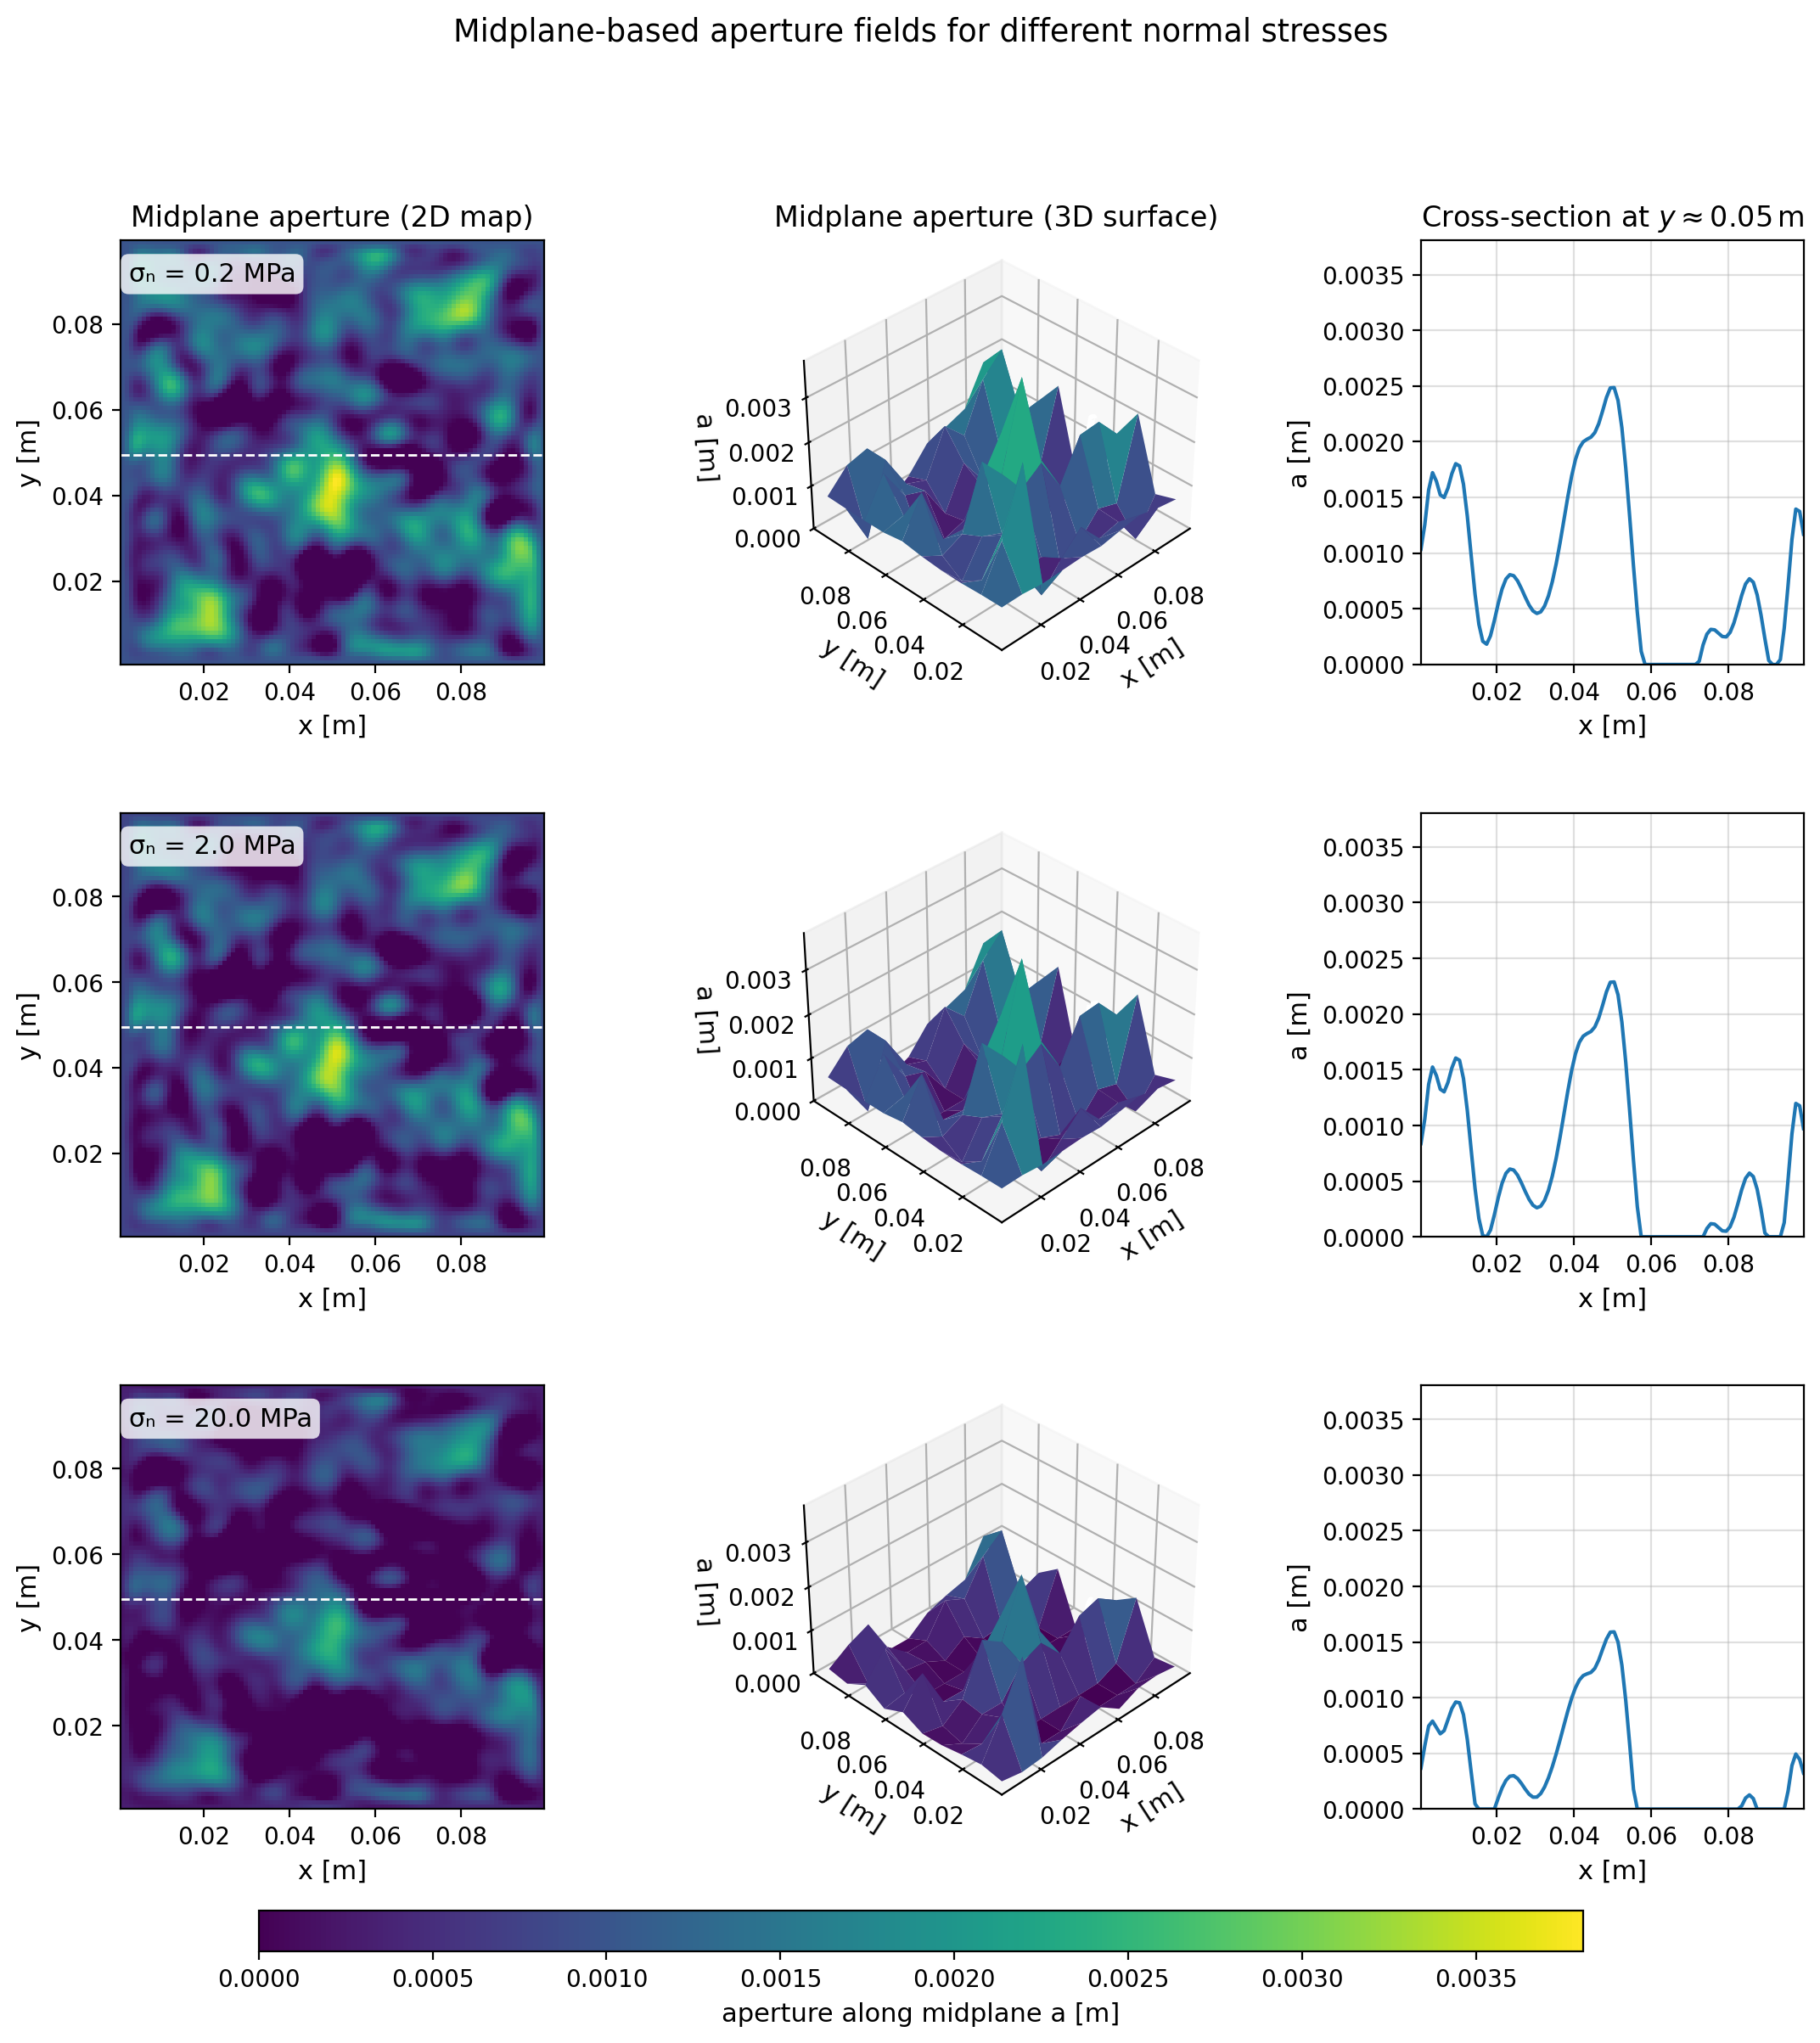

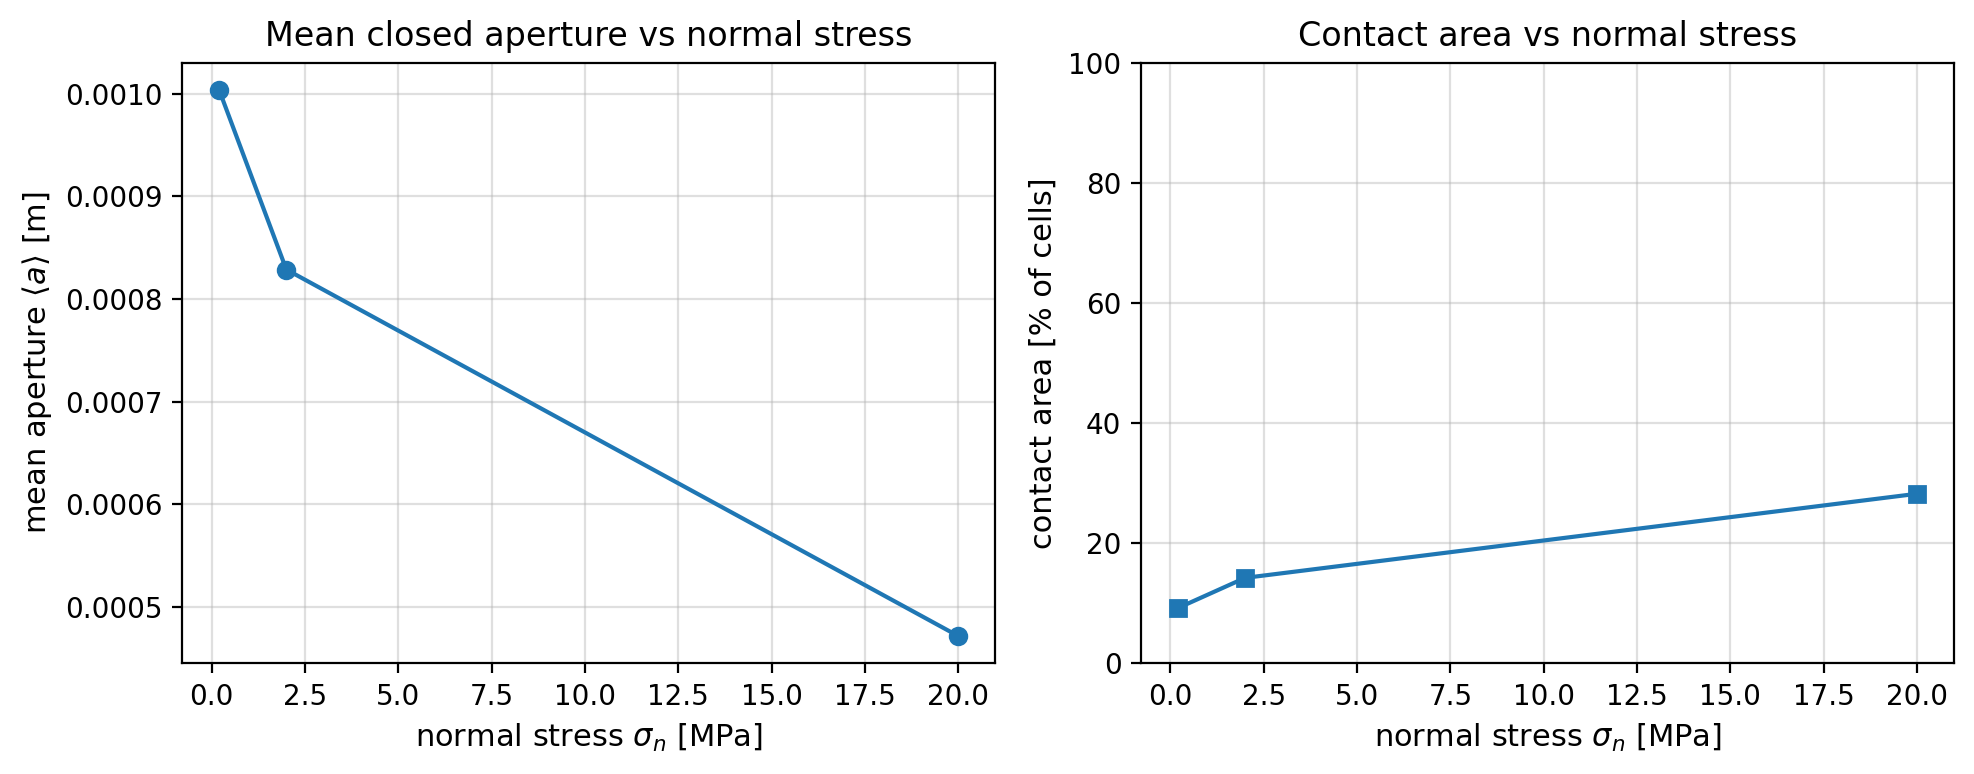

In [4]:
if __name__ == "__main__":

    # 1) Generate initial mated surfaces (single source: CFG)
    x, y, z_lower, z_upper = generate_correlated_surfaces(
        jrc=CFG["jrc"],
        seed=CFG["seed"],
        lambda_min=CFG["lambda_min"],
        lambda_max=CFG["lambda_max"],
        b0=CFG["b0"],
    )

    x_cells = 0.5 * (x[:-1] + x[1:])
    y_cells = 0.5 * (y[:-1] + y[1:])

    sigmas_mpa = CFG["sigmas_mpa"]

    # results containers
    z_lower_damaged = {}
    z_upper_slid = {}
    aperture_midplanes = {}

    stats_mean_raw = {}
    stats_mean_closed = {}
    stats_contact_raw = {}
    stats_contact_closed = {}
    stats_delta_bn = {}

    for sigma_n in sigmas_mpa:
        print(f"\n=== σ_n = {sigma_n} MPa ===")

        # 2) Damage (choose wall once, via CFG)
        if CFG["damage_wall"] == "upper":
            z_dmg = casagrande_shear_v3(
                surface=z_upper,
                sigma_n_mpa=sigma_n,
                dx=CFG["dx"], dy=CFG["dy"],
                direction=CFG["direction"],
                b_step_deg=CFG["b_step_deg"],
                max_outer=CFG["max_outer"],
                verbose=CFG["verbose"],
            )
            dzmax = float(np.max(np.abs(z_dmg - z_upper)))
            print(f"  max |z_up_dmg - z_upper| = {dzmax:.3e} m")

            z_up_slid = slide_upper_one_cell_x(z_dmg)
            a_raw = compute_midplane_aperture(z_lower, z_up_slid, CFG["dx"], CFG["dy"])

            z_lower_damaged[sigma_n] = z_lower
            z_upper_slid[sigma_n] = z_up_slid

        elif CFG["damage_wall"] == "lower":
            z_dmg = casagrande_shear_v3(
                surface=z_lower,
                sigma_n_mpa=sigma_n,
                dx=CFG["dx"], dy=CFG["dy"],
                direction=CFG["direction"],
                b_step_deg=CFG["b_step_deg"],
                max_outer=CFG["max_outer"],
                verbose=CFG["verbose"],
            )
            dzmax = float(np.max(np.abs(z_dmg - z_lower)))
            print(f"  max |z_low_dmg - z_lower| = {dzmax:.3e} m")

            z_up_slid = slide_upper_one_cell_x(z_upper)
            a_raw = compute_midplane_aperture(z_dmg, z_up_slid, CFG["dx"], CFG["dy"])

            z_lower_damaged[sigma_n] = z_dmg
            z_upper_slid[sigma_n] = z_up_slid

        else:
            raise ValueError("CFG['damage_wall'] must be 'upper' or 'lower'")

        # 3) raw contact
        contact_raw = float(np.mean(a_raw <= 0.0) * 100.0)

        # 4) normal closure
        a_mid, delta_b_n = apply_bandis_normal_closure(a_raw, sigma_n, b0=CFG["b0"])
        contact_closed = float(np.mean(a_mid <= 0.0) * 100.0)

        print(f"  % cells with a_raw < Δb_n = {np.mean(a_raw < delta_b_n) * 100:.2f} %")

        mean_raw = float(a_raw.mean())
        mean_closed = float(a_mid.mean())

        print(f"  mean(a_raw)       = {mean_raw:.3e} m")
        print(f"  contact_raw%      = {contact_raw:6.2f} %")
        print(f"  Δb_n (Bandis)     = {delta_b_n:.3e} m")
        print(f"  mean(a_closed)    = {mean_closed:.3e} m")
        print(f"  contact_closed%   = {contact_closed:6.2f} %")

        # store
        aperture_midplanes[sigma_n] = a_mid
        stats_mean_raw[sigma_n] = mean_raw
        stats_mean_closed[sigma_n] = mean_closed
        stats_contact_raw[sigma_n] = contact_raw
        stats_contact_closed[sigma_n] = contact_closed
        stats_delta_bn[sigma_n] = delta_b_n

    # 5) Global color scale
    all_aperture_values = np.concatenate([aperture_midplanes[s].ravel() for s in sigmas_mpa])
    amin = 0.0
    amax = float(np.max(all_aperture_values))
    print(f"Global aperture range: [{amin:.3e}, {amax:.3e}] m")

    # 6) Cross-section definition
    j_mid_cell = (len(y_cells) - 1) // 2
    y_mid_value = y_cells[j_mid_cell]
    Xc, Yc = np.meshgrid(x_cells, y_cells, indexing="ij")

    # 7) Multi-panel plot
    n_sigma = len(sigmas_mpa)
    fig = plt.figure(figsize=(13, 4 * n_sigma))

    gs = mpl.gridspec.GridSpec(
        n_sigma, 3,
        width_ratios=[1.0, 1.1, 0.8],
        wspace=0.35,
        hspace=0.35
    )

    im_for_cbar = None
    stride = CFG["stride"]

    for row, sigma_n in enumerate(sigmas_mpa):
        a_mid = aperture_midplanes[sigma_n]

        ax2d = fig.add_subplot(gs[row, 0])
        im = ax2d.imshow(
            a_mid.T,
            origin="lower",
            extent=(x_cells[0], x_cells[-1], y_cells[0], y_cells[-1]),
            aspect="equal",
            vmin=amin, vmax=amax,
            cmap="viridis",
        )
        if im_for_cbar is None:
            im_for_cbar = im

        ax2d.axhline(y_mid_value, color="white", linestyle="--", linewidth=1.0)

        if row == 0:
            ax2d.set_title("Midplane aperture (2D map)")
        ax2d.set_xlabel("x [m]")
        ax2d.set_ylabel("y [m]")

        ax2d.text(
            0.02, 0.95,
            fr"σₙ = {sigma_n} MPa",
            transform=ax2d.transAxes,
            ha="left", va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, linewidth=0.0),
        )

        ax3d = fig.add_subplot(gs[row, 1], projection="3d")
        X_plot = Xc[::stride, ::stride]
        Y_plot = Yc[::stride, ::stride]
        Z_plot = a_mid[::stride, ::stride]

        ax3d.plot_surface(
            X_plot, Y_plot, Z_plot,
            rstride=1, cstride=1,
            linewidth=0,
            antialiased=True,
            cmap="viridis",
            vmin=amin, vmax=amax,
        )

        aperture_line_3d = a_mid[:, j_mid_cell]
        ax3d.plot(
            x_cells,
            np.full_like(x_cells, y_mid_value),
            aperture_line_3d,
            color="white", linestyle="--",
            linewidth=3,
        )

        ax3d.set_xlim(x_cells[0], x_cells[-1])
        ax3d.set_ylim(y_cells[0], y_cells[-1])
        ax3d.set_zlim(amin, amax)
        ax3d.set_xlabel("x [m]")
        ax3d.set_ylabel("y [m]")
        ax3d.set_zlabel("a [m]")
        ax3d.view_init(elev=35, azim=-135)
        if row == 0:
            ax3d.set_title("Midplane aperture (3D surface)")

        ax1d = fig.add_subplot(gs[row, 2])
        aperture_line = a_mid[:, j_mid_cell]
        ax1d.plot(x_cells, aperture_line, lw=1.5)

        ax1d.set_xlim(x_cells[0], x_cells[-1])
        ax1d.set_ylim(amin, amax)
        ax1d.set_xlabel("x [m]")
        if row == 0:
            ax1d.set_title(fr"Cross-section at $y \approx {y_mid_value:.2f}\,\mathrm{{m}}$")
        ax1d.set_ylabel("a [m]")
        ax1d.grid(True, alpha=0.4)

    cbar_ax = fig.add_axes([0.20, 0.04, 0.60, 0.02])
    cbar = fig.colorbar(im_for_cbar, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("aperture along midplane a [m]")

    fig.suptitle("Midplane-based aperture fields for different normal stresses", y=0.99)
    plt.tight_layout(rect=[0.03, 0.08, 0.97, 0.96])

    # 8) Mean aperture & contact vs sigma
    fig2, axes = plt.subplots(1, 2, figsize=(10, 4))

    sig_arr = np.array(sigmas_mpa, dtype=float)
    mean_closed_arr = np.array([stats_mean_closed[s] for s in sigmas_mpa])
    contact_arr = np.array([stats_contact_closed[s] for s in sigmas_mpa])

    ax_mean = axes[0]
    ax_mean.plot(sig_arr, mean_closed_arr, marker="o", lw=1.5)
    ax_mean.set_xlabel(r"normal stress $\sigma_n$ [MPa]")
    ax_mean.set_ylabel(r"mean aperture $\langle a \rangle$ [m]")
    ax_mean.set_title("Mean closed aperture vs normal stress")
    ax_mean.grid(True, alpha=0.4)

    ax_c = axes[1]
    ax_c.plot(sig_arr, contact_arr, marker="s", lw=1.5)
    ax_c.set_xlabel(r"normal stress $\sigma_n$ [MPa]")
    ax_c.set_ylabel("contact area [% of cells]")
    ax_c.set_title("Contact area vs normal stress")
    ax_c.set_ylim(0.0, 100.0)
    ax_c.grid(True, alpha=0.4)

    fig2.tight_layout()
    plt.show()


# Save the upper and lower surfaces in VTK format for specific $\sigma_n$ just for visualization

In [5]:
def write_vtk_joint_structured(
    x,
    y,
    z_lower,
    z_upper,
    a_mid,
    filename,
    contact_tol=1e-12,
    write_cell_types=True,
    write_point_data=False,
    eps_log=1e-15,
    also_write_vtu=True,          
    vtu_filename=None,            
    remove_legacy_vtk=False,      
):
    """
    ... (same docstring)
    also_write_vtu : bool
        If True, convert the written legacy .vtk STRUCTURED_GRID to a .vtu
        UnstructuredGrid (keeps hex cells + CELL_DATA) using PyVista.
    vtu_filename : str|None
        Output .vtu path. If None, uses filename with extension replaced by .vtu.
    remove_legacy_vtk : bool
        If True, delete the legacy .vtk after successful conversion.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z_lower = np.asarray(z_lower, dtype=float)
    z_upper = np.asarray(z_upper, dtype=float)
    a_mid = np.asarray(a_mid, dtype=float)

    nx = x.size
    ny = y.size
    nz_dim = 2

    if z_lower.shape != (nx, ny):
        raise ValueError(f"z_lower.shape={z_lower.shape} must be (nx, ny)=({nx}, {ny})")
    if z_upper.shape != (nx, ny):
        raise ValueError(f"z_upper.shape={z_upper.shape} must be (nx, ny)=({nx}, {ny})")
    if a_mid.shape != (nx - 1, ny - 1):
        raise ValueError(f"a_mid.shape={a_mid.shape} must be (nx-1, ny-1)=({nx-1}, {ny-1})")

    n_points = nx * ny * nz_dim
    n_cells = (nx - 1) * (ny - 1) * (nz_dim - 1)

    zL_c = 0.25 * (z_lower[:-1, :-1] + z_lower[1:, :-1] + z_lower[:-1, 1:] + z_lower[1:, 1:])
    zU_c = 0.25 * (z_upper[:-1, :-1] + z_upper[1:, :-1] + z_upper[:-1, 1:] + z_upper[1:, 1:])
    z_mid = 0.5 * (zL_c + zU_c)

    contact_cells = (a_mid <= float(contact_tol)).astype(np.int32)
    open_cells = (1 - contact_cells).astype(np.int32)
    log_aperture = np.log10(np.maximum(a_mid, 0.0) + float(eps_log))

    if write_point_data:
        a_pt = np.zeros((nx, ny), dtype=float)
        c_pt = np.zeros((nx, ny), dtype=float)
        w_pt = np.zeros((nx, ny), dtype=float)

        for di, dj in [(0, 0), (1, 0), (0, 1), (1, 1)]:
            a_pt[di:nx - 1 + di, dj:ny - 1 + dj] += a_mid
            c_pt[di:nx - 1 + di, dj:ny - 1 + dj] += contact_cells
            w_pt[di:nx - 1 + di, dj:ny - 1 + dj] += 1.0

        w_pt = np.where(w_pt == 0.0, 1.0, w_pt)
        a_pt /= w_pt
        c_pt = (c_pt / w_pt)

        a_pt_layers = [a_pt, a_pt]
        c_pt_layers = [c_pt, c_pt]

    # -------- write legacy VTK ----------
    with open(filename, "w") as f:
        f.write("# vtk DataFile Version 3.0\n")
        f.write("Fracture joint: lower+upper walls + aperture/contact cell data\n")
        f.write("ASCII\n")
        f.write("DATASET STRUCTURED_GRID\n")
        f.write(f"DIMENSIONS {nx} {ny} {nz_dim}\n")
        f.write(f"POINTS {n_points} float\n")

        for k in range(nz_dim):
            for j in range(ny):
                yj = y[j]
                for i in range(nx):
                    xi = x[i]
                    zij = z_lower[i, j] if k == 0 else z_upper[i, j]
                    f.write(f"{xi:.6e} {yj:.6e} {zij:.6e}\n")

        f.write(f"\nCELL_DATA {n_cells}\n")

        f.write("SCALARS aperture_mid float 1\nLOOKUP_TABLE default\n")
        for j in range(ny - 1):
            for i in range(nx - 1):
                f.write(f"{a_mid[i, j]:.6e}\n")

        f.write("\nSCALARS contact int 1\nLOOKUP_TABLE default\n")
        for j in range(ny - 1):
            for i in range(nx - 1):
                f.write(f"{int(contact_cells[i, j])}\n")

        f.write("\nSCALARS open int 1\nLOOKUP_TABLE default\n")
        for j in range(ny - 1):
            for i in range(nx - 1):
                f.write(f"{int(open_cells[i, j])}\n")

        f.write("\nSCALARS z_mid float 1\nLOOKUP_TABLE default\n")
        for j in range(ny - 1):
            for i in range(nx - 1):
                f.write(f"{z_mid[i, j]:.6e}\n")

        f.write("\nSCALARS log_aperture float 1\nLOOKUP_TABLE default\n")
        for j in range(ny - 1):
            for i in range(nx - 1):
                f.write(f"{log_aperture[i, j]:.6e}\n")

        if write_cell_types:
            f.write(f"\nCELL_TYPES {n_cells}\n")
            for _ in range(n_cells):
                f.write("12\n")

        if write_point_data:
            f.write(f"\nPOINT_DATA {n_points}\n")
            f.write("SCALARS aperture_pt float 1\nLOOKUP_TABLE default\n")
            for k in range(nz_dim):
                a_layer = a_pt_layers[k]
                for j in range(ny):
                    for i in range(nx):
                        f.write(f"{a_layer[i, j]:.6e}\n")

            f.write("\nSCALARS contact_frac_pt float 1\nLOOKUP_TABLE default\n")
            for k in range(nz_dim):
                c_layer = c_pt_layers[k]
                for j in range(ny):
                    for i in range(nx):
                        f.write(f"{c_layer[i, j]:.6e}\n")

    # -------- convert to VTU ----------
    if also_write_vtu:
        import os
        import pyvista as pv

        if vtu_filename is None:
            root, _ext = os.path.splitext(filename)
            vtu_filename = root + ".vtu"

        grid = pv.read(filename)
        ugrid = grid.cast_to_unstructured_grid()
        ugrid.save(vtu_filename)

        if remove_legacy_vtk:
            os.remove(filename)

    return filename


In [6]:
def run_sigma_damage_lower_slide_upper_write_vtk(
    cfg: dict,
    sigma_n_mpa: float,
    vtk_basename: str = "joint.vtk",
    out_dir: str | Path | None = None,
):
    """
    Fixed scenario (simple):
      - damage LOWER wall
      - slide UPPER wall by one cell in +x
      - compute midplane aperture
      - write VTK into out_dir

    You only provide sigma_n_mpa; everything else comes from cfg.
    """

    # --------- output path ----------
    out_dir = Path(out_dir if out_dir is not None else cfg.get("out_dir", "_out"))
    out_dir.mkdir(parents=True, exist_ok=True)
    vtk_path = out_dir / vtk_basename

    # --------- grid + tolerances ----------
    dx = float(cfg.get("dx", cfg.get("DX")))
    dy = float(cfg.get("dy", cfg.get("DY")))
    contact_tol = float(cfg.get("contact_tol", cfg.get("CONTACT_TOL", 1e-12)))

    # --------- 1) mated surfaces ----------
    x, y, z_lower, z_upper = generate_correlated_surfaces(
        jrc=cfg["jrc"],
        seed=cfg["seed"],
        lambda_min=cfg["lambda_min"],
        lambda_max=cfg["lambda_max"],
        b0=cfg["b0"],
    )

    # --------- 2) damage LOWER ----------
    z_lower_damaged = casagrande_shear_v3(
        surface=z_lower,
        sigma_n_mpa=float(sigma_n_mpa),
        dx=dx, dy=dy,
        direction=cfg.get("direction", "x"),
        b_step_deg=float(cfg.get("b_step_deg", 0.5)),
        max_outer=int(cfg.get("max_outer", 50)),
        verbose=bool(cfg.get("verbose", False)),
    )

    # --------- 3) slide UPPER ----------
    z_upper_slid = slide_upper_one_cell_x(z_upper)

    # --------- 4) midplane aperture ----------
    a_mid = compute_midplane_aperture(z_lower_damaged, z_upper_slid, dx, dy)

    # --------- 5) VTK export ----------
    write_vtk_joint_structured(
        x=x, y=y,
        z_lower=z_lower_damaged,
        z_upper=z_upper_slid,
        a_mid=a_mid,
        filename=str(vtk_path),
        contact_tol=contact_tol,
    )

    return {
        "vtk_path": str(vtk_path),
        "x": x, "y": y,
        "z_lower_damaged": z_lower_damaged,
        "z_upper_slid": z_upper_slid,
        "a_mid": a_mid,
        "sigma_n_mpa": float(sigma_n_mpa),
    }


In [7]:
CFG["out_dir"] = "_out"

out = run_sigma_damage_lower_slide_upper_write_vtk(
    CFG,
    sigma_n_mpa=2.0,
    vtk_basename="joint_sigma_2MPa.vtk",
)

print("Saved to:", out["vtk_path"])


ERROR:root:Unsupported cell attribute type: cell_types for file: /Volumes/Projects/RiskXclude/roughfracture/_out/joint_sigma_2MPa.vtk
2026-01-19 15:18:48.221 (   2.228s) [          37D727]      vtkDataReader.cxx:854    ERR| vtkStructuredGridReader (0x11a1ec780): Unsupported cell attribute type: cell_types for file: /Volumes/Projects/RiskXclude/roughfracture/_out/joint_sigma_2MPa.vtk


Saved to: _out/joint_sigma_2MPa.vtk


# Save the mid surface as fracture and conformed 3D cube mesh  in VTK format for specific $\sigma_n$ for simulation

In [8]:
def make_stretched_z_coords(
    cube_height: float,
    n_layers: int,
    stretch_exponent: float = 1.0,
) -> np.ndarray:
    """
    Non-uniform z-coordinates for height cube_height.

    Total z points = 2*n_layers + 1
    fracture plane at z=0 (middle index).
    stretch_exponent > 1 -> finer near z=0.
    """
    z_half = cube_height / 2.0
    s = np.linspace(0.0, 1.0, n_layers + 1)
    s_stretched = s**stretch_exponent

    z_pos = z_half * s_stretched
    z_neg = -z_pos[1:][::-1]
    return np.concatenate([z_neg, z_pos])


def create_conformal_cube_with_embedded_fracture(
    surface_vtk_file: str,
    cube_height: float = 1.0,
    n_layers: int = 20,
    stretch_exponent: float = 2.0,
    out_dir: str | None = "_out",
    out_basename: str | None = None,
    symmetric_blend: bool = False,
):
    """
    Build a conformal 3D structured cube mesh and embed a rough fracture surface
    at the mid z-layer, then create a combined unstructured mesh with:
      - 3D hex cells (bulk) + MaterialID {1(bottom),2(top)}
      - 2D quad cells (fracture) sharing nodes + MaterialID {3}

    Fracture fields (cell_data) are mapped only onto the 2D fracture quads
    in the combined mesh; bulk cells get zeros for those arrays.

    IMPORTANT:
      - Input surface should be a VTK STRUCTURED_GRID (like your writer output).
      - Ordering is preserved using VTK's native i-fastest ordering (Fortran reshape).
    """

    surface_vtk_file = str(surface_vtk_file)
    
    if not os.path.exists(surface_vtk_file):
        raise FileNotFoundError(f"Surface VTK file not found: {surface_vtk_file}")

    out_dir = "_out" if out_dir is None else out_dir
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if out_basename is None:
        out_basename = Path(surface_vtk_file).stem

    print(f"Creating conformal cube from surface: {surface_vtk_file}")

    # ---------------------------------------------------------------------
    # 0) Read surface and use STRUCTURED_GRID dimensions (no sorting!)
    # ---------------------------------------------------------------------
    surface_mesh = pv.read(surface_vtk_file)    
    # --- sanitize: remove problematic/reserved arrays that can break VTK readers
    for bad in ["cell_types", "vtkOriginalCellIds", "vtkOriginalPointIds"]:
        if bad in surface_mesh.cell_data:
            print(f"Removing cell_data '{bad}' (can break StructuredGrid readers)")
            surface_mesh.cell_data.pop(bad)
        if bad in surface_mesh.point_data:
            print(f"Removing point_data '{bad}' (not needed here)")
            surface_mesh.point_data.pop(bad)

    
    if not hasattr(surface_mesh, "dimensions"):
        raise TypeError(
            "Input surface is not a StructuredGrid/Structured type with 'dimensions'. "
            "Your input should be a VTK STRUCTURED_GRID (like from write_vtk_joint_structured)."
        )

    nx, ny, nz_in = surface_mesh.dimensions  # points in each dir
    print(f"Loaded surface: points={surface_mesh.n_points}, cells={surface_mesh.n_cells}")
    print(f"Surface dimensions: nx={nx}, ny={ny}, nz={nz_in}")

    pts = surface_mesh.points
    expected_points = nx * ny * nz_in
    if pts.shape[0] != expected_points:
        raise ValueError(
            f"StructuredGrid has dimensions {surface_mesh.dimensions} "
            f"but points={pts.shape[0]} != nx*ny*nz={expected_points}."
        )

    # Reshape points in VTK ordering (i fastest -> Fortran order)
    pts4 = pts.reshape((nx, ny, nz_in, 3), order="F")
    x_coords = pts4[:, 0, 0, 0].copy()  # x varies with i
    y_coords = pts4[0, :, 0, 1].copy()  # y varies with j

    z_layers = pts4[:, :, :, 2]                 # [nx,ny,nz_in]
    z_eff = np.mean(z_layers, axis=2)           # effective mid-surface z(x,y)
    deformation = z_eff - float(np.mean(z_eff)) # remove mean (embed as zero-mean roughness)

    # ---------------------------------------------------------------------
    # 0b) Map surface cell_data to 2D fracture cell arrays (keep cell-based!)
    # ---------------------------------------------------------------------
    # StructuredGrid cells count = (nx-1)*(ny-1)*(nz_in-1)
    cells_per_layer = (nx - 1) * (ny - 1)
    expected_cells = cells_per_layer * max(nz_in - 1, 1)

    if surface_mesh.n_cells != expected_cells:
        print(
            f"WARNING: surface cells={surface_mesh.n_cells}, expected={expected_cells}. "
            "Cell_data mapping may not be correct."
        )

    fracture_cell_2d: dict[str, np.ndarray] = {}
    if nz_in < 2:
        print("WARNING: surface has nz<2; cannot interpret as lower+upper wall structure.")
    else:
        n_cell_layers = nz_in - 1  # for nz_in=2 -> 1 layer of cells
        for name in surface_mesh.cell_data.keys():
            data = np.asarray(surface_mesh.cell_data[name])

            if data.shape[0] != surface_mesh.n_cells:
                print(f"Skipping cell_data '{name}' (len mismatch).")
                continue

            # reshape in VTK cell ordering (i fastest -> Fortran)
            if data.ndim == 1:
                arr = data.reshape((nx - 1, ny - 1, n_cell_layers), order="F")
                cell2d = np.mean(arr, axis=2)  # [nx-1, ny-1]
            elif data.ndim == 2:
                n_comp = data.shape[1]
                arr = data.reshape((nx - 1, ny - 1, n_cell_layers, n_comp), order="F")
                cell2d = np.mean(arr, axis=2)  # [nx-1, ny-1, n_comp]
            else:
                print(f"Skipping cell_data '{name}' with shape {data.shape}")
                continue

            fracture_cell_2d[name] = cell2d
            print(f"   ↳ mapped cell_data '{name}' -> {cell2d.shape}")

    # ---------------------------------------------------------------------
    # 1) Create 3D structured cube grid with stretched z
    # ---------------------------------------------------------------------
    z_coords = make_stretched_z_coords(
        cube_height=cube_height,
        n_layers=n_layers,
        stretch_exponent=stretch_exponent,
    )
    nz = len(z_coords)
    fracture_layer = nz // 2
    fracture_z_level = float(z_coords[fracture_layer])  # ~ 0

    xx, yy, zz = np.meshgrid(x_coords, y_coords, z_coords, indexing="ij")

    # embed roughness at fracture layer
    zz[:, :, fracture_layer] = fracture_z_level + deformation

    # blend away from fracture (top always; bottom optional)
    # top
    for k in range(fracture_layer + 1, nz):
        blend = (k - fracture_layer) / (nz - 1 - fracture_layer)
        zz[:, :, k] = z_coords[k] + deformation * (1.0 - blend)

    # bottom
    if symmetric_blend:
        for k in range(0, fracture_layer):
            blend = (fracture_layer - k) / fracture_layer
            zz[:, :, k] = z_coords[k] + deformation * (1.0 - blend)
    else:
        # keep bottom flat (your original behavior)
        for k in range(0, fracture_layer):
            zz[:, :, k] = z_coords[k]

    volume_mesh = pv.StructuredGrid(xx, yy, zz)

    # ---------------------------------------------------------------------
    # 2) Build structured 2D fracture surface (for reference)
    # ---------------------------------------------------------------------
    # Keep it consistent with VTK ordering by passing arrays
    fx = xx[:, :, fracture_layer][:, :, None]
    fy = yy[:, :, fracture_layer][:, :, None]
    fz = zz[:, :, fracture_layer][:, :, None]
    fracture_surface = pv.StructuredGrid(fx, fy, fz)

    # attach fracture cell_data to fracture_surface
    n_quads = (nx - 1) * (ny - 1)
    for name, cell2d in fracture_cell_2d.items():
        if cell2d.ndim == 2:
            # cell2d is [nx-1, ny-1] -> ravel with VTK ordering
            fracture_surface.cell_data[name] = cell2d.ravel(order="F")
        elif cell2d.ndim == 3:
            # [nx-1, ny-1, n_comp] -> [n_quads, n_comp]
            n_comp = cell2d.shape[2]
            fracture_surface.cell_data[name] = cell2d.reshape(n_quads, n_comp, order="F")

    fracture_surface.cell_data["MaterialID"] = np.full(n_quads, 3, dtype=np.int32)

    # ---------------------------------------------------------------------
    # 3) Assign MaterialID to 3D bulk cells
    # ---------------------------------------------------------------------
    centers_z = volume_mesh.cell_centers().points[:, 2]
    mat_3d = np.where(centers_z > fracture_z_level, 2, 1).astype(np.int32)
    volume_mesh.cell_data["MaterialID"] = mat_3d

    # convert to unstructured (hexes)
    hex_ugrid = volume_mesh.cast_to_unstructured_grid()
    points = hex_ugrid.points
    cells_hex = hex_ugrid.cells
    celltypes_hex = hex_ugrid.celltypes
    n_hex_cells = hex_ugrid.n_cells

    # ---------------------------------------------------------------------
    # 4) Build 2D fracture quad cells (shared nodes!)
    # ---------------------------------------------------------------------
    quad_cells = []
    # VTK structured point indexing: p(i,j,k) = i + nx*(j + ny*k)
    k = fracture_layer
    for j in range(ny - 1):
        for i in range(nx - 1):
            p0 = i + nx * (j + ny * k)
            p1 = (i + 1) + nx * (j + ny * k)
            p2 = (i + 1) + nx * ((j + 1) + ny * k)
            p3 = i + nx * ((j + 1) + ny * k)
            quad_cells.extend([4, p0, p1, p2, p3])

    cells_quads = np.array(quad_cells, dtype=cells_hex.dtype)
    celltypes_quads = np.full(n_quads, pv.CellType.QUAD, dtype=celltypes_hex.dtype)

    # -------------------------------------------------------------------------
    # Step 5 : Assign MaterialID for 3D cells by k-layer (robust)
    # -------------------------------------------------------------------------
    print("Step 5: Assigning MaterialID to 3D cells (rock) by k-layer...")
    
    nxp, nyp, nzp = volume_mesh.dimensions          # point dims: (nx, ny, nz)
    nxc, nyc, nzc = nxp - 1, nyp - 1, nzp - 1       # cell dims
    fracture_layer = nzp // 2                       # point-layer index of fracture
    fracture_cell_k = fracture_layer - 1            # last cell-layer below fracture
    
    material_ids_3d = np.empty(volume_mesh.n_cells, dtype=np.int32)
    
    cid = 0
    for k in range(nzc):
        mat = 1 if k <= fracture_cell_k else 2      # bottom=1, top=2
        for j in range(nyc):
            for i in range(nxc):
                material_ids_3d[cid] = mat
                cid += 1
    
    assert cid == volume_mesh.n_cells, "MaterialID fill mismatch vs number of 3D cells."
    volume_mesh.cell_data["MaterialID"] = material_ids_3d


    # -------------------------------------------------------------------------
    # Step 6: Convert structured volume to unstructured hex mesh
    # -------------------------------------------------------------------------
    print("Step 6: Converting volume to unstructured hex mesh...")
    hex_ugrid = volume_mesh.cast_to_unstructured_grid()
    
    points = hex_ugrid.points
    cells_hex = hex_ugrid.cells
    celltypes_hex = hex_ugrid.celltypes
    n_hex_cells = hex_ugrid.n_cells
    
    # MaterialID is CELL data 
    mat_hex = np.array(hex_ugrid.cell_data["MaterialID"], dtype=np.int32)
    
    # -------------------------------------------------------------------------
    # Step 7: Build 2D quad cells for fracture (shared nodes)
    # -------------------------------------------------------------------------
    print("Step 7: Building 2D quad cells for the fracture (shared nodes)...")
    
    n_quads = (nx - 1) * (ny - 1)
    quad_cells_list = []
    
    # VTK structured ordering: point_id = i + nx*(j + ny*k)
    for j in range(ny - 1):
        for i in range(nx - 1):
            p0 = i + nx * (j + ny * fracture_layer)
            p1 = (i + 1) + nx * (j + ny * fracture_layer)
            p2 = (i + 1) + nx * ((j + 1) + ny * fracture_layer)
            p3 = i + nx * ((j + 1) + ny * fracture_layer)
            quad_cells_list.extend([4, p0, p1, p2, p3])
    
    cells_quads = np.array(quad_cells_list, dtype=cells_hex.dtype)
    celltypes_quads = np.full(n_quads, pv.CellType.QUAD, dtype=celltypes_hex.dtype)
    
    # -------------------------------------------------------------------------
    # Step 8: Combine into one UnstructuredGrid  (THIS CREATES combined_mesh)
    # -------------------------------------------------------------------------
    print("Step 8: Combining 3D hex + 2D quad into one mesh...")
    
    cells_combined = np.concatenate([cells_hex, cells_quads])
    celltypes_combined = np.concatenate([celltypes_hex, celltypes_quads])
    
    combined_mesh = pv.UnstructuredGrid(cells_combined, celltypes_combined, points)
    
    # MaterialID for combined cells: bulk (1,2) then fracture (3)
    mat_frac = np.full(n_quads, 3, dtype=np.int32)
    combined_mesh.cell_data["MaterialID"] = np.concatenate([mat_hex, mat_frac])
    
    # -------------------------------------------------------------------------
    # Step 9: Map fracture fields onto combined mesh (bulk=0, fracture=values)
    # -------------------------------------------------------------------------
    print("Step 9: Mapping fracture cell-based fields into 3D+2D mesh...")
    
    n_cells_combined = combined_mesh.n_cells
    
    for name, cell2d in fracture_cell_2d.items():
        if cell2d.ndim == 2:
            frac_vals = cell2d.ravel(order="F").astype(float)
            all_vals = np.zeros(n_cells_combined, dtype=float)
            all_vals[n_hex_cells:] = frac_vals
            combined_mesh.cell_data[name] = all_vals
    
        elif cell2d.ndim == 3:
            nx2, ny2, n_comp = cell2d.shape            
            assert nx2 == nx - 1 and ny2 == ny - 1
            frac_vals = cell2d.reshape(n_quads, n_comp, order="F").astype(float)
            all_vals = np.zeros((n_cells_combined, n_comp), dtype=float)
            all_vals[n_hex_cells:, :] = frac_vals
            combined_mesh.cell_data[name] = all_vals

    
    # -------------------------------------------------------------------------
    # Step 10: Save outputs (make sure this is AFTER combined_mesh exists)
    # -------------------------------------------------------------------------
    print("Step 10: Saving output meshes (ALL UNSTRUCTURED .vtu)...")
    
    bulk_file     = os.path.join(out_dir, f"{out_basename}_bulk_hex.vtu")
    fracture_file = os.path.join(out_dir, f"{out_basename}_fracture_quads.vtu")
    combined_file = os.path.join(out_dir, f"{out_basename}_bulk_plus_fracture.vtu")
    
    # bulk unstructured hex mesh (already created)
    hex_ugrid.save(bulk_file)
    
    # fracture-only unstructured quad mesh (shared points)
    fracture_ugrid = pv.UnstructuredGrid(cells_quads, celltypes_quads, points)
    fracture_ugrid.cell_data["MaterialID"] = np.full(n_quads, 3, dtype=np.int32)
    
    # attach fracture fields directly (no bulk padding here!)
    for name, cell2d in fracture_cell_2d.items():
        if cell2d.ndim == 2:
            fracture_ugrid.cell_data[name] = cell2d.ravel(order="F").astype(float)
        elif cell2d.ndim == 3:
            n_comp = cell2d.shape[2]
            fracture_ugrid.cell_data[name] = cell2d.reshape(n_quads, n_comp, order="F").astype(float)
    
    fracture_ugrid.save(fracture_file)
    
    # combined unstructured mesh
    combined_mesh.save(combined_file)
    
    print(" Saved:")
    print("  ", bulk_file)
    print("  ", fracture_file)
    print("  ", combined_file)

    return volume_mesh, fracture_surface, combined_mesh



In [9]:
# 1) Your input fracture surface VTK (the 2-layer structured grid you wrote)
surface_vtk = "_out/joint_sigma_2MPa.vtk"   # change to your file

# 2) Build the “box + embedded fracture” and save outputs into out_dir
vol_mesh, frac_surf, combo = create_conformal_cube_with_embedded_fracture(
    surface_vtk_file=surface_vtk,
    cube_height=CFG["lx_user"],          # total box height (z from -0.5 to +0.5 if symmetric_blend=False)
    n_layers=20,              # layers per half -> total z points = 2*n_layers+1
    stretch_exponent=2.0,     # >1 = finer near fracture plane
    out_dir="_out_cube",      # output folder
    out_basename="case_sigma2",
    symmetric_blend=False,    # True if you also want bottom half to smoothly blend
)


ERROR:root:Unsupported cell attribute type: cell_types for file: /Volumes/Projects/RiskXclude/roughfracture/_out/joint_sigma_2MPa.vtk
2026-01-19 15:18:48.307 (   2.314s) [          37D727]      vtkDataReader.cxx:854    ERR| vtkStructuredGridReader (0x11a1f2450): Unsupported cell attribute type: cell_types for file: /Volumes/Projects/RiskXclude/roughfracture/_out/joint_sigma_2MPa.vtk


Creating conformal cube from surface: _out/joint_sigma_2MPa.vtk
Loaded surface: points=20402, cells=10000
Surface dimensions: nx=101, ny=101, nz=2
   ↳ mapped cell_data 'aperture_mid' -> (100, 100)
   ↳ mapped cell_data 'contact' -> (100, 100)
   ↳ mapped cell_data 'open' -> (100, 100)
   ↳ mapped cell_data 'z_mid' -> (100, 100)
   ↳ mapped cell_data 'log_aperture' -> (100, 100)
Step 5: Assigning MaterialID to 3D cells (rock) by k-layer...
Step 6: Converting volume to unstructured hex mesh...
Step 7: Building 2D quad cells for the fracture (shared nodes)...
Step 8: Combining 3D hex + 2D quad into one mesh...
Step 9: Mapping fracture cell-based fields into 3D+2D mesh...
Step 10: Saving output meshes (ALL UNSTRUCTURED .vtu)...
 Saved:
   _out_cube/case_sigma2_bulk_hex.vtu
   _out_cube/case_sigma2_fracture_quads.vtu
   _out_cube/case_sigma2_bulk_plus_fracture.vtu


# Test

In [10]:
# ============================================================
# TEST_CFG (single source of truth for ALL tests)
# ============================================================

import numpy as np
import math

TEST_CFG = {
    # --------------------------------------------------------
    # 0) Meta
    # --------------------------------------------------------
    "print_banner": True,
    "verbose": True,

    # --------------------------------------------------------
    # 1) Required symbols check (API contract)
    # --------------------------------------------------------
    "required_symbols": [
        "generate_surface_stigsson",
        "generate_correlated_surfaces",
        "_calculate_sigma_dh",
        "casagrande_shear_v3",
        "compute_midplane_aperture",
        "slide_upper_one_cell_x",
        "compute_apparent_dip_signed",
        "get_phi_and_jcs_table",
        "apply_bandis_normal_closure",
        "get_H_and_sigma1mm_from_JRC",
    ],

    # --------------------------------------------------------
    # 2) Grid / geometry for synthetic tests
    #    (used for flat-plate and synthetic Bandis tests)
    # --------------------------------------------------------
    "synthetic": {
        "nx": 101,
        "ny": 101,
        "dx": 1.0e-3,
        "dy": 1.0e-3,
        "b0": 1.0e-3,
    },

    # --------------------------------------------------------
    # 3) get_H_and_sigma1mm_from_JRC tests
    # --------------------------------------------------------
    "H_sigma_test": {
        # test at anchors and midpoints (engineering: interp + strict range)
        "jrc_values_inside": [4.0, 5.5, 7.0, 8.5, 10.0],
        "jrc_values_outside": [3.999, 10.001],
        "tol_H_abs": 1e-12,
        "tol_sigma_abs": 1e-12,
    },

    # --------------------------------------------------------
    # 4) φ(σn), JCS(σn) table tests
    # --------------------------------------------------------
    "phi_jcs_test": {
        "anchors": [
            # (sigma_mpa, phi_deg_expected, jcs_mpa_expected)
            (0.2, 60.0, 209.0),
            (2.0, 50.0, 153.0),
            (20.0, 30.0, 97.0),
        ],
        "sigma_outside": [0.1999, 20.0001],
        "sigma_near_anchors": [
            # (sigma_mpa, phi_deg_ref, jcs_mpa_ref)
            (0.2001, 60.0, 209.0),
            (1.9999, 50.0, 153.0),
            (2.0001, 50.0, 153.0),
            (19.9999, 30.0, 97.0),
        ],
        # engineering tolerances: "must be near" (not discontinuous)
        "tol_phi_near_deg": 0.5,
        "tol_jcs_near_mpa": 5.0,
        "tol_anchor_abs": 1e-9,  # anchors should match almost exactly
    },

    # --------------------------------------------------------
    # 5) Wavelength band strictness tests
    # --------------------------------------------------------
    "lambda_band_test": {
        # Engineering: lambda_min too small for dx=1 mm must raise
        "jrc": 7,
        "seed": 0,
        "lambda_min_bad": 2e-3,
        # IMPORTANT: lambda_max_good must be <= min(CFG["lx"], CFG["ly"])
        # To avoid coupling tests to your domain, we read from CFG at runtime.
        # If you prefer: set explicit lambda_max_good here after you set CFG domain.
        "lambda_min_good": 4e-3,
        "lambda_max_good_key": "lambda_max",  # use CFG["lambda_max"] by default
    },

    # --------------------------------------------------------
    # 6) sigma_dh calibration test
    # --------------------------------------------------------
    "sigma_dh_test": {
        "jrc": 7,
        "seeds": [0, 1, 2, 3, 4],
        "rel_err_max": 0.05,  # <= 5% average relative error
    },

    # --------------------------------------------------------
    # 7) PSD slope test (1D midline)
    # --------------------------------------------------------
    "psd_test": {
        "jrc": 7,
        "seed": 0,
    
        # IMPORTANT: for PSD slope test we must disable geometry post-processing
        # (taper/detrend distort the spectrum and steepen the PSD slope)
        "disable_detrend": True,
        "disable_edge_taper": True,
    
        # Fit only inside the active k-band implied by lambda_min/lambda_max
        # (avoids “too few points” when band is narrow)
        "k_margin_low": 1.3,   # fit starts at 1.3*k_min_user
        "k_margin_high": 0.7,  # fit ends   at 0.7*k_max_user
        "min_fit_points": 12,
    
        "slope_must_be_less_than": -0.5,
        "tol_abs": 1.0,
    },



    # --------------------------------------------------------
    # 8) Casagrande / clipping tests
    # --------------------------------------------------------
    "damage_test": {
        "jrc": 7,
        "seed": 0,
        "direction": "x",
        # engineering: clipping should NOT increase max |beta|
        "sigma_for_beta_test": 2.0,
        "max_outer_beta": 10,
        "b_step_deg_beta": 0.5,
        "beta_increase_tol_deg": 1e-6,
        # engineering: at high sigma, damage should be nonzero (detect regression)
        "sigma_high": 20.0,
        "max_outer_high": 10,
        "b_step_deg_high": 1.0,
        "min_damage_dzmax": 0.0,  # >0 means some change must happen
    },

    # --------------------------------------------------------
    # 9) Bandis closure monotonicity tests
    # --------------------------------------------------------
    "bandis_test": {
        "sigmas_mpa": [0.2, 2.0, 10.0, 20.0],
        "noise_std_frac_of_b0": 0.10,  # synthetic aperture noise level
        "monotonic_tol": 1e-12,
    },
}


# Test the implementation

In [11]:
# ============================================================
# TEST SUITE (all numeric criteria come from TEST_CFG)
# ============================================================

def _require(name: str):
    if name not in globals():
        raise RuntimeError(
            f"Missing required symbol: {name}. "
            f"Run the model code cell(s) that define `{name}` first."
        )

def assert_raises(exc_type, fn, *args, **kwargs):
    try:
        fn(*args, **kwargs)
    except exc_type:
        return
    except Exception as e:
        raise AssertionError(f"Expected {exc_type.__name__}, got {type(e).__name__}: {e}") from e
    raise AssertionError(f"Expected {exc_type.__name__}, but no exception was raised.")

def summarize_aperture(a: np.ndarray, label: str = ""):
    a_flat = a.ravel()
    stats = {
        "mean": float(np.mean(a_flat)),
        "std": float(np.std(a_flat)),
        "min": float(np.min(a_flat)),
        "max": float(np.max(a_flat)),
        "contact_ratio": float(np.mean(a_flat <= 0.0)),
    }
    print(f"--- Aperture stats [{label}] ---")
    print(f"  mean(a)   = {stats['mean']:.3e} m")
    print(f"  std(a)    = {stats['std']:.3e} m")
    print(f"  min(a)    = {stats['min']:.3e} m")
    print(f"  max(a)    = {stats['max']:.3e} m")
    print(f"  contact%  = {100.0*stats['contact_ratio']:5.2f} %")
    return stats

def compute_max_beta(surface: np.ndarray, dx: float, dy: float, direction: str) -> float:
    beta_deg = compute_apparent_dip_signed(surface, dx, dy, direction=direction)
    return float(np.max(np.abs(beta_deg)))

def estimate_psd_slope_1d(z_line, dx, fmin_frac, fmax_frac):
    n = len(z_line)
    Z = np.fft.rfft(z_line - np.mean(z_line))
    freqs = np.fft.rfftfreq(n, d=dx)
    S = (np.abs(Z) ** 2) / n

    mask = freqs > 0
    freqs = freqs[mask]
    S = S[mask]

    i0 = int(fmin_frac * len(freqs))
    i1 = int(fmax_frac * len(freqs))
    i0 = max(i0, 1)
    i1 = max(i1, i0 + 10)

    freqs_band = freqs[i0:i1]
    S_band = S[i0:i1]

    x = np.log10(freqs_band)
    y = np.log10(S_band)

    slope = float(np.polyfit(x, y, 1)[0])
    return slope, (float(freqs_band[0]), float(freqs_band[-1]))

# ------------------------------------------------------------
# 0) Sanity check
# ------------------------------------------------------------
def test_required_symbols(TC):
    for name in TC["required_symbols"]:
        _require(name)
    print(">> test_required_symbols: PASSED")

# ------------------------------------------------------------
# 1) get_H and sigma strict + interpolation behavior
# ------------------------------------------------------------
def test_get_H_sigma_strict_and_interp(TC):
    cfg = TC["H_sigma_test"]
    # outside range must fail
    for j in cfg["jrc_values_outside"]:
        assert_raises(ValueError, get_H_and_sigma1mm_from_JRC, j)

    # inside range returns finite values
    for j in cfg["jrc_values_inside"]:
        H, sig = get_H_and_sigma1mm_from_JRC(j)
        assert np.isfinite(H) and np.isfinite(sig)
        assert H > 0.0
        assert sig > 0.0

    print(">> test_get_H_sigma_strict_and_interp: PASSED")

# ------------------------------------------------------------
# 2) phi/JCS table exact anchors + strict range + smoothness
# ------------------------------------------------------------
def test_phi_jcs_table(TC):
    cfg = TC["phi_jcs_test"]

    for (s, phi_exp, jcs_exp) in cfg["anchors"]:
        phi_rad, jcs_pa = get_phi_and_jcs_table(s)
        phi_deg = math.degrees(phi_rad)
        jcs_mpa = jcs_pa / 1e6

        assert abs(phi_deg - phi_exp) < cfg["tol_anchor_abs"]
        assert abs(jcs_mpa - jcs_exp) < cfg["tol_anchor_abs"]

    for s in cfg["sigma_outside"]:
        assert_raises(ValueError, get_phi_and_jcs_table, s)

    for (s, phi_ref, jcs_ref) in cfg["sigma_near_anchors"]:
        phi_rad, jcs_pa = get_phi_and_jcs_table(s)
        phi_deg = math.degrees(phi_rad)
        jcs_mpa = jcs_pa / 1e6

        assert abs(phi_deg - phi_ref) < cfg["tol_phi_near_deg"]
        assert abs(jcs_mpa - jcs_ref) < cfg["tol_jcs_near_mpa"]

    print(">> test_phi_jcs_table: PASSED")

# ------------------------------------------------------------
# 3) lambda band strictness
# ------------------------------------------------------------
def test_lambda_band_strict(TC):
    cfg = TC["lambda_band_test"]
    jrc = cfg["jrc"]
    seed = cfg["seed"]

    # bad lambda_min must fail (regression check)
    assert_raises(ValueError, generate_surface_stigsson, jrc, seed, cfg["lambda_min_bad"], CFG["lambda_max"])

    # good lambda_min and domain-consistent lambda_max must work
    lambda_max_good = CFG[cfg["lambda_max_good_key"]]  # typically CFG["lambda_max"]
    x, y, z = generate_surface_stigsson(jrc=jrc, seed=seed,
                                        lambda_min=cfg["lambda_min_good"],
                                        lambda_max=lambda_max_good)
    assert z.shape == (CFG["nx"], CFG["ny"])
    assert len(x) == CFG["nx"] and len(y) == CFG["ny"]

    print(">> test_lambda_band_strict: PASSED")

# ------------------------------------------------------------
# 4) sigma_dh calibration
# ------------------------------------------------------------
def test_sigma_dh_calibration(TC):
    cfg = TC["sigma_dh_test"]
    _, sigma_target = get_H_and_sigma1mm_from_JRC(cfg["jrc"])

    vals = []
    for seed in cfg["seeds"]:
        _, _, z = generate_surface_stigsson(jrc=cfg["jrc"], seed=seed)
        vals.append(_calculate_sigma_dh(z))

    mean_val = float(np.mean(vals))
    rel_err = abs(mean_val - sigma_target) / sigma_target

    print(f"Target sigma_dh = {sigma_target:.6e} m")
    print(f"Mean   sigma_dh = {mean_val:.6e} m")
    print(f"Rel error       = {100.0*rel_err:.2f} %")

    assert rel_err < cfg["rel_err_max"], "sigma_dh calibration drifted beyond limit"

    print(">> test_sigma_dh_calibration: PASSED")

# ------------------------------------------------------------
# 5) PSD slope test (1D midline)
# ------------------------------------------------------------
def test_psd_slope_1d(TC: dict):
    cfg = TC["psd_test"]

    # --- raw surface (NO detrend / NO taper) for spectral law test
    x, y, z = generate_surface_stigsson(
        jrc=cfg["jrc"],
        seed=cfg["seed"],
        lambda_min=CFG["lambda_min"],
        lambda_max=CFG["lambda_max"],
    )

    # 1D profile (midline)
    prof = z[:, z.shape[1] // 2]
    prof = prof - np.mean(prof)

    dx = float(CFG["dx"])
    n = prof.size

    # 1D PSD
    fft = np.fft.rfft(prof)
    psd = (np.abs(fft) ** 2) / n  # scale not important for slope
    k = 2.0 * np.pi * np.fft.rfftfreq(n, d=dx)  # rad/m



    # --- build safe fit band from lambda band
    lam_min = float(CFG["lambda_min"])
    lam_max = float(CFG["lambda_max"])
    k_min = 2.0 * np.pi / lam_max
    k_max = 2.0 * np.pi / lam_min

    # Start conservative, then relax if needed
    lo = 1.3
    hi = 0.7

    def make_mask(lo_factor, hi_factor):
        k_fit_min = lo_factor * k_min
        k_fit_max = hi_factor * k_max
        mask = (k >= k_fit_min) & (k <= k_fit_max) & (psd > 0) & (k > 0)
        return mask, k_fit_min, k_fit_max

    mask, k_fit_min, k_fit_max = make_mask(lo, hi)

    # Required points: scale with n (small domains can't hit 10 bins)
    min_pts = max(6, min(10, n // 12))  # e.g. n=72 -> 6, n=200 -> 10

    # Relax margins gradually until enough points or until full band
    for _ in range(12):
        if np.count_nonzero(mask) >= min_pts:
            break
        lo = max(1.0, lo - 0.05)   # move toward k_min
        hi = min(1.0, hi + 0.05)   # move toward k_max
        mask, k_fit_min, k_fit_max = make_mask(lo, hi)

    if np.count_nonzero(mask) < max(4, min_pts):
        raise AssertionError(
            f"Too few PSD points in fit band even after relaxing margins. "
            f"count={np.count_nonzero(mask)}, "
            f"k_fit=[{k_fit_min:.2e}, {k_fit_max:.2e}] rad/m, "
            f"available=[{k[1]:.2e}, {k[-1]:.2e}] rad/m. "
            f"Increase nx or use longer profile for PSD."
        )

    # log-log fit
    logk = np.log10(k[mask])
    logS = np.log10(psd[mask])
    slope, intercept = np.polyfit(logk, logS, 1)

    # expected slope for 1D profile extracted from 2D self-affine surface
    H, _ = get_H_and_sigma1mm_from_JRC(cfg["jrc"])
    expected = -(2.0 * H + 1.0)

    band = (float(k_fit_min), float(k_fit_max))
    print(f"PSD slope = {slope:.3f}, expected ~ {expected:.3f}, k_fit(rad/m)={band}")

    assert slope < cfg["slope_must_be_less_than"]
    assert abs(slope - expected) < cfg["tol_abs"]

    print(">> test_psd_slope_1d: PASSED")

# ------------------------------------------------------------
# 6) Casagrande clipping must not increase max |beta|
# ------------------------------------------------------------
def test_clipping_beta(TC):
    cfg = TC["damage_test"]

    x, y, _, z_upper = generate_correlated_surfaces(jrc=cfg["jrc"], seed=cfg["seed"])
    dx = float(x[1] - x[0])
    dy = float(y[1] - y[0])

    beta_before = compute_max_beta(z_upper, dx, dy, cfg["direction"])
    z_dmg = casagrande_shear_v3(
        surface=z_upper,
        sigma_n_mpa=cfg["sigma_for_beta_test"],
        dx=dx, dy=dy,
        direction=cfg["direction"],
        b_step_deg=cfg["b_step_deg_beta"],
        max_outer=cfg["max_outer_beta"],
        verbose=False,
    )
    beta_after = compute_max_beta(z_dmg, dx, dy, cfg["direction"])

    print(f"beta max before={beta_before:.3f}°, after={beta_after:.3f}°")
    assert beta_after <= beta_before + cfg["beta_increase_tol_deg"]

    print(">> test_clipping_beta: PASSED")

# ------------------------------------------------------------
# 7) High sigma should produce nonzero damage (detect "no-op")
# ------------------------------------------------------------
def test_damage_nonzero_at_high_sigma(TC):
    cfg = TC["damage_test"]

    x, y, _, z_upper = generate_correlated_surfaces(jrc=cfg["jrc"], seed=cfg["seed"])
    dx = float(x[1] - x[0])
    dy = float(y[1] - y[0])

    z_dmg = casagrande_shear_v3(
        surface=z_upper,
        sigma_n_mpa=cfg["sigma_high"],
        dx=dx, dy=dy,
        direction=cfg["direction"],
        b_step_deg=cfg["b_step_deg_high"],
        max_outer=cfg["max_outer_high"],
        verbose=False,
    )

    dzmax = float(np.max(np.abs(z_dmg - z_upper)))
    print(f"max |Δz| at σ_n={cfg['sigma_high']} MPa = {dzmax:.3e} m")
    assert dzmax > cfg["min_damage_dzmax"], "Expected nonzero damage at high σ_n"

    print(">> test_damage_nonzero_at_high_sigma: PASSED")

# ------------------------------------------------------------
# 8) Bandis closure monotonicity (engineering invariants)
# ------------------------------------------------------------
def test_bandis_closure_monotonic(TC):
    cfg = TC["bandis_test"]
    syn = TC["synthetic"]

    rng = np.random.default_rng(123)
    nx, ny = syn["nx"], syn["ny"]
    b0 = syn["b0"]

    a0 = b0 + (cfg["noise_std_frac_of_b0"] * b0) * rng.standard_normal((nx, ny))
    a0 = np.maximum(a0, 0.0)

    sigmas = cfg["sigmas_mpa"]
    means, contacts, closures = [], [], []

    for s in sigmas:
        a_closed, delta_b = apply_bandis_normal_closure(a0, s, b0=b0)
        stats = summarize_aperture(a_closed, label=f"Bandis σ_n={s} MPa")
        means.append(stats["mean"])
        contacts.append(stats["contact_ratio"])
        closures.append(delta_b)
        print(f"σ_n={s:5.2f} MPa: Δb_n={delta_b:.3e} m")

    tol = cfg["monotonic_tol"]
    for i in range(1, len(sigmas)):
        assert closures[i] > closures[i-1] - tol, "Δb_n must be non-decreasing with σ_n"
        assert means[i] <= means[i-1] + tol,      "mean(a) must be non-increasing with σ_n"
        assert contacts[i] >= contacts[i-1] - tol,"contact ratio must be non-decreasing with σ_n"

    print(">> test_bandis_closure_monotonic: PASSED")

# ------------------------------------------------------------
# Runner
# ------------------------------------------------------------
def run_all_tests(TC=TEST_CFG):
    if TC["print_banner"]:
        print("\n==============================")
        print(" Running fracture model tests ")
        print("==============================")

    test_required_symbols(TC)
    test_get_H_sigma_strict_and_interp(TC)
    test_phi_jcs_table(TC)
    test_lambda_band_strict(TC)
    test_sigma_dh_calibration(TC)
    test_clipping_beta(TC)
    test_damage_nonzero_at_high_sigma(TC)
    test_bandis_closure_monotonic(TC)
    test_psd_slope_1d(TC)


    print("\nALL TESTS PASSED")


In [12]:
run_all_tests(TEST_CFG)


 Running fracture model tests 
>> test_required_symbols: PASSED
>> test_get_H_sigma_strict_and_interp: PASSED
>> test_phi_jcs_table: PASSED
>> test_lambda_band_strict: PASSED
Target sigma_dh = 1.440000e-04 m
Mean   sigma_dh = 1.417787e-04 m
Rel error       = 1.54 %
>> test_sigma_dh_calibration: PASSED
beta max before=15.086°, after=15.086°
>> test_clipping_beta: PASSED
max |Δz| at σ_n=20.0 MPa = 4.830e-04 m
>> test_damage_nonzero_at_high_sigma: PASSED
--- Aperture stats [Bandis σ_n=0.2 MPa] ---
  mean(a)   = 9.700e-04 m
  std(a)    = 9.969e-05 m
  min(a)    = 5.770e-04 m
  max(a)    = 1.330e-03 m
  contact%  =  0.00 %
σ_n= 0.20 MPa: Δb_n=3.077e-05 m
--- Aperture stats [Bandis σ_n=2.0 MPa] ---
  mean(a)   = 7.722e-04 m
  std(a)    = 9.969e-05 m
  min(a)    = 3.792e-04 m
  max(a)    = 1.132e-03 m
  contact%  =  0.00 %
σ_n= 2.00 MPa: Δb_n=2.286e-04 m
--- Aperture stats [Bandis σ_n=10.0 MPa] ---
  mean(a)   = 4.674e-04 m
  std(a)    = 9.969e-05 m
  min(a)    = 7.443e-05 m
  max(a)    = 8.